# Trabajo Práctico Integrador — Análisis de Datos
## TMDB Movies Dataset

El presente trabajo tiene como objetivo realizar un análisis exploratorio y la preparación de un conjunto de datos de películas de TMDB para un posible problema de Machine Learning supervisado.

A lo largo del análisis se estudiará la estructura del dataset, la calidad de los datos, las distribuciones de las variables, la presencia de valores faltantes y outliers, y las relaciones entre las distintas características. Posteriormente se realizará el preprocesamiento necesario para dejar los datos preparados para el entrenamiento de un modelo supervisado.

El dataset utilizado corresponde a **TMDB Movies Dataset**.

## 1. Configuración del entorno

Se importan las librerías necesarias para la manipulación, análisis y visualización de los datos.

Durante las primeras etapas se utilizarán principalmente `pandas` y `numpy` para el procesamiento de datos, y `matplotlib` y `seaborn` para las visualizaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Definición de rutas

Se definen las rutas del proyecto para mantener separados los datos originales, las notebooks de análisis y las figuras generadas.


In [127]:
from pathlib import Path

BASE_PATH = Path(
    r"C:\Users\julif\Documents\Especialización IA\Análisis de datos\TP_TMDB"
)

DATA_PATH = BASE_PATH / "data"
FIGURES_PATH = BASE_PATH / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

csv_path = DATA_PATH / "TMDB_movie_dataset_v11.csv"

print("Directorio del proyecto:", BASE_PATH)
print("Dataset encontrado:", csv_path.exists())
print("Ruta del dataset:", csv_path)

Directorio del proyecto: C:\Users\julif\Documents\Especialización IA\Análisis de datos\TP_TMDB
Dataset encontrado: True
Ruta del dataset: C:\Users\julif\Documents\Especialización IA\Análisis de datos\TP_TMDB\data\TMDB_movie_dataset_v11.csv


## 3. Inspección inicial del dataset

El archivo original posee un tamaño considerable, por lo que antes de cargarlo completamente en memoria se realiza una lectura de una pequeña muestra.

El objetivo de esta primera inspección es verificar:

- la correcta lectura del archivo;
- las variables disponibles;
- la estructura general de los registros;
- los tipos de datos inferidos inicialmente por `pandas`.

En esta etapa se leen únicamente las primeras cinco observaciones.

In [128]:
df_sample = pd.read_csv(csv_path, nrows=5)

df_sample

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [13]:
df_sample.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [14]:
print(f"Dimensiones de la muestra: {df_sample.shape}")

print("\nVariables disponibles:")
display(pd.DataFrame({
    "Variable": df_sample.columns,
    "Tipo": df_sample.dtypes.astype(str).values
}))

Dimensiones de la muestra: (5, 24)

Variables disponibles:


,Variable,Tipo
0,id,int64
1,title,str
2,vote_average,float64
3,vote_count,int64
4,status,str
5,release_date,str
6,revenue,int64
7,runtime,int64
8,adult,bool
9,backdrop_path,str


### Observaciones iniciales

La muestra contiene **24 variables** con información de distinta naturaleza.

Se observan variables numéricas, como `vote_average`, `vote_count`, `revenue`, `runtime`, `budget` y `popularity`; variables categóricas o textuales, como `status`, `original_language`, `genres` y `production_companies`; y una variable temporal, `release_date`, que inicialmente es interpretada como texto.

También existen variables principalmente identificatorias o descriptivas, como `id`, `title`, `imdb_id`, `homepage`, `overview`, `poster_path` y `backdrop_path`.

Esta inspección es solamente preliminar. Los tipos inferidos a partir de cinco registros deberán verificarse nuevamente una vez cargado el dataset completo.

## 4. Dimensión del dataset completo

Antes de cargar el archivo completo se determina el número total de observaciones disponibles.

Dado el tamaño del archivo, se contabilizan inicialmente las filas utilizando únicamente una columna, reduciendo así el consumo de memoria.

In [16]:
n_rows = pd.read_csv(
    csv_path,
    usecols=["id"]
).shape[0]

print(f"Número total de películas: {n_rows:,}")

Número total de películas: 1,476,851


### Evaluación preliminar del tamaño y los tipos de datos

El dataset contiene **1.476.851 observaciones**. Debido a su tamaño, antes de cargarlo completamente se analiza una muestra más amplia de 10.000 registros.

Esta muestra permite estimar el consumo de memoria, verificar los tipos de datos inferidos por `pandas` y detectar posibles problemas de calidad sin necesidad de cargar inicialmente todo el archivo.

In [17]:
df_sample_10k = pd.read_csv(
    csv_path,
    nrows=10_000
)

print(f"Dimensiones de la muestra: {df_sample_10k.shape}")

memory_mb = df_sample_10k.memory_usage(deep=True).sum() / 1024**2

print(f"Memoria utilizada por 10.000 filas: {memory_mb:.2f} MB")

estimated_memory_gb = memory_mb * (n_rows / 10_000) / 1024

print(
    f"Memoria estimada para el dataset completo: "
    f"{estimated_memory_gb:.2f} GB"
)

Dimensiones de la muestra: (10000, 24)
Memoria utilizada por 10.000 filas: 14.91 MB
Memoria estimada para el dataset completo: 2.15 GB


In [18]:
df_sample_10k.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10000 non-null  int64  
 1   title                 10000 non-null  str    
 2   vote_average          10000 non-null  float64
 3   vote_count            10000 non-null  int64  
 4   status                10000 non-null  str    
 5   release_date          10000 non-null  str    
 6   revenue               10000 non-null  int64  
 7   runtime               10000 non-null  int64  
 8   adult                 10000 non-null  bool   
 9   backdrop_path         9988 non-null   str    
 10  budget                10000 non-null  int64  
 11  homepage              4098 non-null   str    
 12  imdb_id               9995 non-null   str    
 13  original_language     10000 non-null  str    
 14  original_title        10000 non-null  str    
 15  overview              9999 non-

In [19]:
summary_types = pd.DataFrame({
    "dtype": df_sample_10k.dtypes,
    "n_unique": df_sample_10k.nunique(),
    "n_missing": df_sample_10k.isna().sum(),
    "missing_%": df_sample_10k.isna().mean() * 100
})

summary_types

,dtype,n_unique,n_missing,missing_%
id,int64,10000,0,0.00
title,str,9648,0,0.00
vote_average,float64,3095,0,0.00
vote_count,int64,3342,0,0.00
status,str,1,0,0.00
release_date,str,6107,0,0.00
revenue,int64,6654,0,0.00
runtime,int64,209,0,0.00
adult,bool,2,0,0.00
backdrop_path,str,9988,12,0.12


### Resultados de la inspección preliminar

La muestra de 10.000 observaciones contiene 24 variables y requiere aproximadamente 14,9 MB de memoria considerando el contenido completo de las variables de texto. Extrapolando este valor al dataset completo, se estima un consumo cercano a 2,15 GB.

La inspección inicial muestra una combinación de variables numéricas, booleanas, temporales y textuales. Algunas variables presentan una proporción considerable de valores faltantes, destacándose `homepage` y `tagline`.

Sin embargo, la ausencia de valores nulos en variables como `budget`, `revenue` o `runtime` no implica necesariamente que la información esté completa, ya que en este tipo de dataset ciertos valores iguales a cero pueden representar información desconocida o no reportada. Esto deberá analizarse posteriormente como parte de la evaluación de calidad de los datos.

Dado que el tamaño estimado resulta manejable, se procederá a cargar el dataset completo, optimizando algunos tipos de datos para reducir el consumo de memoria.

In [20]:
dtype_map = {
    "id": "int32",
    "vote_average": "float32",
    "vote_count": "int32",
    "revenue": "int64",
    "runtime": "int32",
    "adult": "bool",
    "budget": "int64",
    "popularity": "float32"
}

df = pd.read_csv(
    csv_path,
    dtype=dtype_map,
    parse_dates=["release_date"],
    low_memory=False
)

print(f"Dimensiones del dataset completo: {df.shape}")

Dimensiones del dataset completo: (1476851, 24)


In [21]:
memory_gb = df.memory_usage(deep=True).sum() / 1024**3

print(f"Memoria utilizada por el DataFrame: {memory_gb:.2f} GB")

Memoria utilizada por el DataFrame: 1.46 GB


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1476851 entries, 0 to 1476850
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   id                    1476851 non-null  int32         
 1   title                 1476832 non-null  str           
 2   vote_average          1476851 non-null  float32       
 3   vote_count            1476851 non-null  int32         
 4   status                1476851 non-null  str           
 5   release_date          1133334 non-null  datetime64[us]
 6   revenue               1476851 non-null  int64         
 7   runtime               1476851 non-null  int32         
 8   adult                 1476851 non-null  bool          
 9   backdrop_path         361519 non-null   str           
 10  budget                1476851 non-null  int64         
 11  homepage              151172 non-null   str           
 12  imdb_id               681123 non-null   str          

In [23]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952003,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.240997,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643005,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.931999,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082001,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## 5. Evaluación de la calidad de los datos

Una vez cargado el dataset completo, se analiza la calidad de la información disponible.

En particular se estudian:

- valores faltantes;
- registros duplicados;
- cantidad de valores únicos por variable;
- presencia de valores iguales a cero en variables donde podrían representar información no reportada.

Esta distinción es relevante porque un valor igual a cero no necesariamente constituye un valor faltante desde el punto de vista técnico, aunque puede representar una ausencia de información desde el punto de vista semántico.

### Valores faltantes

Se cuantifica la cantidad y el porcentaje de valores faltantes presentes en cada variable del dataset.

Este análisis permite identificar qué columnas presentan mayor pérdida de información y anticipar posibles estrategias de tratamiento durante la etapa de preprocesamiento.

La presencia de valores faltantes no implica necesariamente el mismo problema en todas las variables. En algunos casos puede tratarse de información no disponible, mientras que en otros puede responder a la propia naturaleza de la variable. Por este motivo, en esta etapa se realiza únicamente una caracterización inicial, sin aplicar todavía imputaciones ni eliminar observaciones.

In [32]:
missing_summary = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("missing_%", ascending=False)
    .round(2)
)

missing_summary

,n_missing,missing_%
homepage,1325679,89.76
tagline,1270233,86.01
keywords,1116941,75.63
backdrop_path,1115332,75.52
production_companies,854889,57.89
imdb_id,795728,53.88
production_countries,725440,49.12
spoken_languages,697176,47.21
genres,659052,44.63
poster_path,535090,36.23


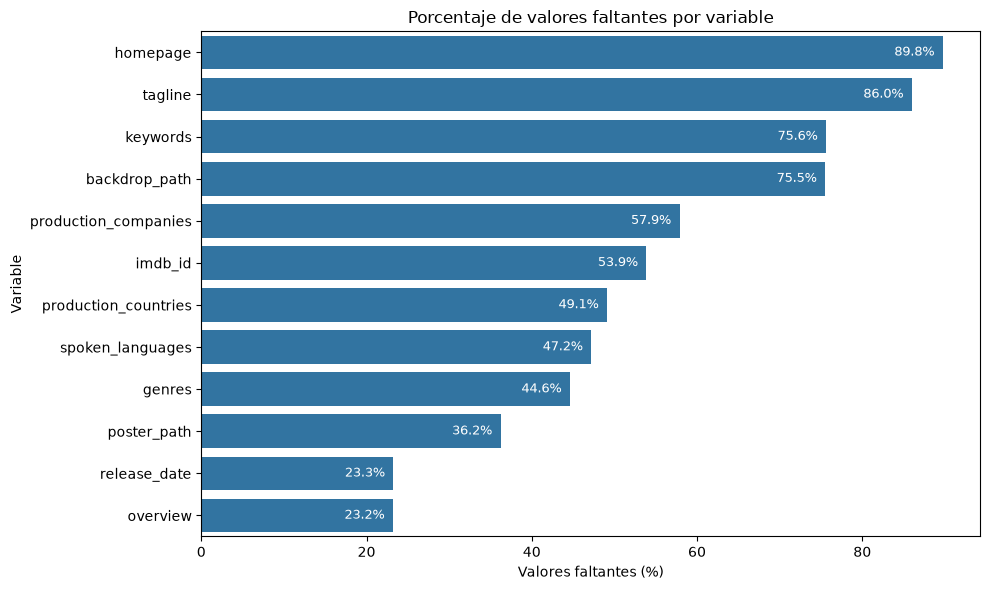

In [28]:
missing_plot = missing_summary[missing_summary["missing_%"] > 0].reset_index()
missing_plot = missing_plot.rename(columns={"index": "variable"})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=missing_plot,
    x="missing_%",
    y="variable"
)

# Etiquetas de porcentaje dentro de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=-35,
        color="white",
        fontsize=9
    )

plt.xlabel("Valores faltantes (%)")
plt.ylabel("Variable")
plt.title("Porcentaje de valores faltantes por variable")

plt.tight_layout()
plt.show()

### Registros duplicados

Se verifica la existencia de observaciones completamente duplicadas y, adicionalmente, de identificadores repetidos.

La variable `id` representa el identificador de cada película, por lo que se espera que sea única.

In [26]:
n_duplicates = df.duplicated().sum()
n_duplicate_ids = df["id"].duplicated().sum()

print(f"Filas completamente duplicadas: {n_duplicates:,}")
print(f"IDs duplicados: {n_duplicate_ids:,}")

Filas completamente duplicadas: 383
IDs duplicados: 1,331


In [27]:
print(f"IDs únicos: {df['id'].nunique():,}")
print(f"Filas totales: {len(df):,}")

IDs únicos: 1,475,520
Filas totales: 1,476,851


### Cardinalidad de las variables

Se analiza la cantidad de valores únicos presentes en cada variable y su proporción respecto del número total de observaciones.

La cardinalidad permite distinguir entre variables con pocas categorías, como `status` u `original_language`, y variables con una gran cantidad de valores distintos, como identificadores, títulos o campos de texto.

Este análisis será útil posteriormente para decidir qué variables pueden utilizarse directamente, cuáles requieren algún tipo de codificación y cuáles podrían resultar poco adecuadas como predictores debido a su elevada cardinalidad.

In [29]:
cardinality = pd.DataFrame({
    "n_unique": df.nunique(dropna=True),
    "unique_%": df.nunique(dropna=True) / len(df) * 100
})

cardinality = cardinality.sort_values("n_unique", ascending=False)

cardinality

,n_unique,unique_%
id,1475520,99.909876
original_title,1290603,87.388843
title,1251667,84.752423
overview,1093822,74.064479
poster_path,935529,63.346201
imdb_id,676256,45.790401
backdrop_path,357662,24.217880
production_companies,242443,16.416213
keywords,209312,14.172858
tagline,197157,13.349823


### Análisis de valores iguales a cero

El análisis de valores iguales a cero se restringe a las variables numéricas en las que este valor puede aportar información relevante sobre la calidad de los datos.

No se incluye `id`, dado que funciona únicamente como identificador, ni las variables categóricas o textuales, para las cuales el concepto de valor cero no resulta aplicable.

Se analizan `vote_average`, `vote_count`, `revenue`, `runtime`, `budget` y `popularity`. Sin embargo, la interpretación del cero no es necesariamente la misma en todas ellas. Por ejemplo, un `vote_count` igual a cero puede representar legítimamente una película que aún no recibió votos, mientras que valores iguales a cero en `budget`, `revenue` o `runtime` podrían representar información desconocida o no reportada.

Por este motivo, en esta etapa los ceros se cuantifican pero no se modifican. Su tratamiento será definido posteriormente en función del significado de cada variable y del problema de Machine Learning seleccionado.

In [33]:
zero_columns = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

zero_summary = pd.DataFrame({
    "n_zero": [(df[col] == 0).sum() for col in zero_columns],
    "zero_%": [(df[col] == 0).mean() * 100 for col in zero_columns]
}, index=zero_columns)

zero_summary.round(2)

,n_zero,zero_%
vote_average,1116732,75.62
vote_count,1116456,75.60
revenue,1451728,98.30
runtime,464863,31.48
budget,1390386,94.15
popularity,265192,17.96


#### Interpretación de los valores iguales a cero

El análisis evidencia una elevada presencia de ceros en varias de las variables numéricas.

En `revenue` y `budget`, los valores iguales a cero representan el 98,30 % y el 94,15 % de las observaciones, respectivamente. La elevada proporción de ceros sugiere que estos valores podrían representar, en gran medida, información no reportada y no necesariamente presupuestos o ingresos efectivamente nulos.”

Por otra parte, `vote_average` y `vote_count` presentan proporciones de ceros prácticamente idénticas (75,62 % y 75,60 %). Esto sugiere a priori una relación entre ambas variables.

La variable `runtime` presenta un 31,48 % de valores iguales a cero. Debido a que una duración de cero minutos no resulta representativa para una película, estos registros podrían corresponder a información de duración no disponible.

Finalmente, `popularity` presenta una proporción menor de ceros (17,96 %). En este caso, el cero podría formar parte legítimamente de la escala utilizada por la variable, por lo que no se considerará inicialmente como un valor faltante.

Estos resultados muestran que la identificación de datos faltantes no puede limitarse únicamente a los valores `NaN`.

### Relación entre ceros en variables numéricas

Dado que algunas variables presentan una proporción elevada de valores iguales a cero, se analiza si estos valores aparecen conjuntamente.

En particular, se estudia la relación entre `vote_count` y `vote_average`, y entre `budget` y `revenue`. Esto permite comprender mejor si los ceros responden a características reales de las películas o a información no disponible.

In [34]:
vote_zero_cross = pd.crosstab(
    df["vote_count"] == 0,
    df["vote_average"] == 0,
    margins=True
)

vote_zero_cross

vote_average,False,True,All
vote_count,,,
False,359531,864,360395
True,588,1115868,1116456
All,360119,1116732,1476851


In [35]:
n_vote_count_zero_average_nonzero = (
    (df["vote_count"] == 0) &
    (df["vote_average"] != 0)
).sum()

n_vote_count_nonzero_average_zero = (
    (df["vote_count"] > 0) &
    (df["vote_average"] == 0)
).sum()

print(
    "vote_count = 0 y vote_average != 0:",
    f"{n_vote_count_zero_average_nonzero:,}"
)

print(
    "vote_count > 0 y vote_average = 0:",
    f"{n_vote_count_nonzero_average_zero:,}"
)

vote_count = 0 y vote_average != 0: 588
vote_count > 0 y vote_average = 0: 864


In [36]:
budget_revenue_zero = pd.crosstab(
    df["budget"] == 0,
    df["revenue"] == 0,
    margins=True
)

budget_revenue_zero

revenue,False,True,All
budget,,,
False,18111,68354,86465
True,7012,1383374,1390386
All,25123,1451728,1476851


In [37]:
usable_counts = pd.Series({
    "vote_count > 0": (df["vote_count"] > 0).sum(),
    "vote_count >= 10": (df["vote_count"] >= 10).sum(),
    "vote_count >= 50": (df["vote_count"] >= 50).sum(),
    "revenue > 0": (df["revenue"] > 0).sum(),
    "budget > 0": (df["budget"] > 0).sum(),
    "budget > 0 y revenue > 0": (
        (df["budget"] > 0) &
        (df["revenue"] > 0)
    ).sum(),
    "runtime > 0": (df["runtime"] > 0).sum()
})

usable_summary = pd.DataFrame({
    "n_observaciones": usable_counts,
    "%_dataset": usable_counts / len(df) * 100
})

usable_summary.round(2)

,n_observaciones,%_dataset
vote_count > 0,360395,24.40
vote_count >= 10,78852,5.34
vote_count >= 50,27981,1.89
revenue > 0,25122,1.70
budget > 0,86465,5.85
budget > 0 y revenue > 0,18110,1.23
runtime > 0,1011987,68.52


## 6. Análisis exploratorio de variables numéricas

A continuación se estudian las principales variables numéricas del dataset con el objetivo de analizar sus distribuciones, rangos, asimetrías y posibles valores atípicos.

Dado que algunas variables presentan una elevada proporción de valores iguales a cero, las distribuciones se analizarán considerando esta característica. En esta etapa no se eliminarán ni imputarán observaciones, ya que el objetivo es comprender primero la estructura original de los datos.

In [38]:
numeric_cols = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
vote_average,1476851.0,1.504088,2.827591e+00,0.0,0.0000,0.0,0.000,1.000000e+01
vote_count,1476851.0,14.530520,2.795384e+02,0.0,0.0000,0.0,0.000,3.449500e+04
revenue,1476851.0,608175.840098,1.956222e+07,-12.0,0.0000,0.0,0.000,5.000000e+09
runtime,1476851.0,43.308196,6.042559e+01,-28.0,0.0000,15.0,85.000,1.440000e+04
budget,1476851.0,231157.365236,5.177824e+06,0.0,0.0000,0.0,0.000,1.000000e+09
popularity,1476851.0,0.972592,6.674605e+00,0.0,0.0143,0.6,0.667,2.994357e+03


### Observaciones iniciales

Las estadísticas descriptivas muestran distribuciones fuertemente asimétricas y una elevada concentración de valores iguales a cero en varias variables.

En particular, `vote_average`, `vote_count`, `budget` y `revenue` presentan un tercer cuartil igual a cero, indicando que al menos el 75 % de las observaciones posee valor cero en estas variables.

También se detectaron valores potencialmente inconsistentes. La variable `revenue` presenta valores negativos y `runtime` contiene tanto duraciones negativas como valores extremadamente elevados. Estos casos serán analizados en mayor detalle antes de definir su tratamiento.

Por otra parte, las grandes diferencias entre las medias, medianas y valores máximos de variables como `budget`, `revenue`, `vote_count` y `popularity` sugieren distribuciones con fuerte asimetría positiva y presencia de valores extremos.

In [40]:
# Valores potencialmente inconsistentes

print("Revenue negativo:", (df["revenue"] < 0).sum())
print("Runtime negativo:", (df["runtime"] < 0).sum())
print("Runtime igual a 0:", (df["runtime"] == 0).sum())
print("Runtime > 300 min:", (df["runtime"] > 300).sum())
print("Budget igual a 0:", (df["budget"] == 0).sum())
print("Revenue igual a 0:", (df["revenue"] == 0).sum())
print("Vote count igual a 0:", (df["vote_count"] == 0).sum())

Revenue negativo: 1
Runtime negativo: 1
Runtime igual a 0: 464863
Runtime > 300 min: 4138
Budget igual a 0: 1390386
Revenue igual a 0: 1451728
Vote count igual a 0: 1116456


In [41]:
df.loc[
    (df["revenue"] < 0) |
    (df["runtime"] < 0) |
    (df["runtime"] > 300),
    ["title", "release_date", "runtime", "budget", "revenue"]
].sort_values("runtime")

,title,release_date,runtime,budget,revenue
525423,An Eye For An Eye,NaT,-28,0,0
195262,Some Bears,2013-05-15,8,12,-12
1264278,Girls Lickin Girls 2,2014-06-12,301,0,0
766648,High Fidelity,2020-02-14,301,0,0
946523,Adventures with the Baumgartners,2017-05-19,301,0,0
...,...,...,...,...,...
987715,Untitled #125 (Hickory),2011-01-01,7200,0,0
307496,Beijing 2003,2004-01-01,9000,0,0
104239,Cinématon,1978-12-20,12480,0,0
984958,Svalbard minutt for minutt,2020-01-31,13319,0,0


### Análisis de valores inconsistentes y extremos

Se identificaron algunos valores claramente inconsistentes. En particular, existe una observación con `revenue = -12` y otra con `runtime = -28`, valores que no poseen una interpretación válida para estas variables y deberán ser corregidos o tratados como faltantes durante la etapa de limpieza.

Por otra parte, se detectaron 4.138 observaciones con duraciones superiores a 300 minutos. La inspección de estos casos muestra que algunos corresponden a producciones de duración excepcionalmente elevada. Por lo tanto, estos valores se consideran inicialmente outliers potencialmente válidos y no serán eliminados de forma automática.

También se observa una elevada cantidad de valores iguales a cero en `runtime`, `budget`, `revenue` y `vote_count`. En particular, la magnitud de los ceros en `budget` y `revenue` sugiere que una parte importante podría corresponder a información no disponible o no reportada. Esta hipótesis será considerada posteriormente al definir la estrategia de preprocesamiento.

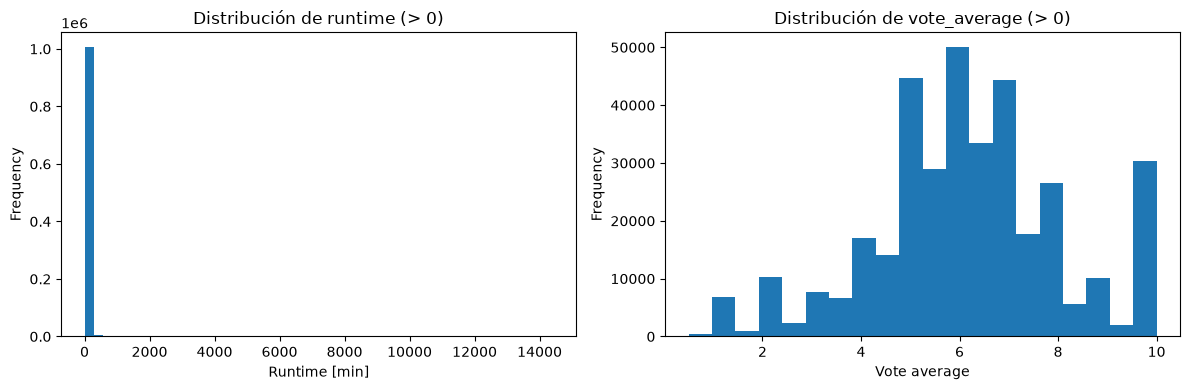

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.loc[df["runtime"] > 0, "runtime"].plot(
    kind="hist",
    bins=50,
    ax=axes[0]
)
axes[0].set_title("Distribución de runtime (> 0)")
axes[0].set_xlabel("Runtime [min]")

df.loc[df["vote_average"] > 0, "vote_average"].plot(
    kind="hist",
    bins=20,
    ax=axes[1]
)
axes[1].set_title("Distribución de vote_average (> 0)")
axes[1].set_xlabel("Vote average")

plt.tight_layout()
plt.show()

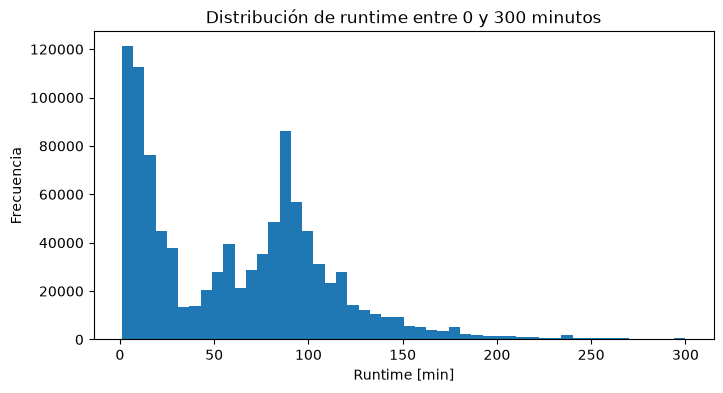

In [44]:
runtime_valid = df.loc[
    (df["runtime"] > 0) & (df["runtime"] <= 300),
    "runtime"
]

plt.figure(figsize=(8,4))
plt.hist(runtime_valid, bins=50)
plt.xlabel("Runtime [min]")
plt.ylabel("Frecuencia")
plt.title("Distribución de runtime entre 0 y 300 minutos")
plt.show()

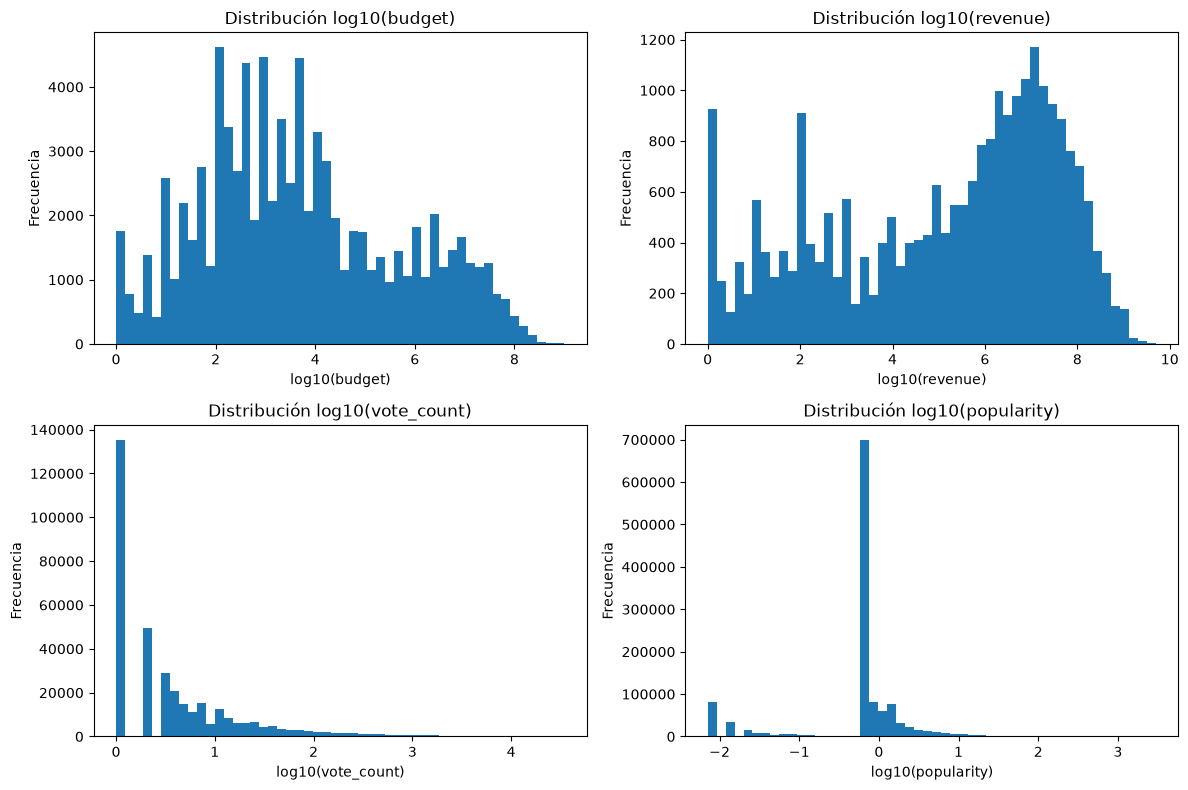

In [43]:
import numpy as np

cols_log = ["budget", "revenue", "vote_count", "popularity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_log):
    values = df.loc[df[col] > 0, col]
    ax.hist(np.log10(values), bins=50)
    ax.set_title(f"Distribución log10({col})")
    ax.set_xlabel(f"log10({col})")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación de las distribuciones

Las variables numéricas presentan distribuciones marcadamente asimétricas.

En `runtime`, la existencia de observaciones con duraciones extremadamente elevadas comprime la distribución principal y dificulta su interpretación, por lo que resultó conveniente visualizar por separado el rango correspondiente a duraciones habituales, sin eliminar inicialmente los valores extremos.

La variable `vote_average` presenta una mayor concentración en valores intermedios, aproximadamente entre 5 y 7, aunque se observan acumulaciones en determinados valores. Su interpretación debe realizarse conjuntamente con `vote_count`, ya que una puntuación promedio basada en pocos votos posee menor representatividad.

Las variables `budget`, `revenue`, `vote_count` y `popularity` presentan una fuerte asimetría positiva. Por esta razón se utilizó una transformación logarítmica exclusivamente con fines de visualización. Incluso luego de dicha transformación se observan concentraciones en determinados valores, lo cual sugiere la existencia de valores discretizados, redondeados o muy frecuentes que deberán ser examinados con mayor detalle.

### Análisis de percentiles y valores frecuentes

Dado que varias variables presentan distribuciones fuertemente asimétricas y valores máximos muy alejados de la mayor parte de los datos, se analizan percentiles altos para caracterizar mejor la distribución sin depender únicamente del valor máximo.

Este análisis permite distinguir entre valores extremos aislados y rangos que, aunque elevados, todavía representan una fracción relevante de las observaciones.

Adicionalmente, se examinan los valores más frecuentes de `popularity`, ya que su histograma mostró una concentración muy marcada en ciertos valores específicos. Esto permite evaluar si existen valores predominantes o posibles valores por defecto dentro del dataset.

In [45]:
percentiles = [0.90, 0.95, 0.99, 0.999]

df[
    ["runtime", "budget", "revenue", "vote_count", "popularity"]
].quantile(percentiles).T

,0.900,0.950,0.990,0.999
runtime,110.0,132.000,203.000,4.780000e+02
budget,0.0,50.000,1000000.000,6.000000e+07
revenue,0.0,0.000,105000.000,1.487041e+08
vote_count,3.0,11.000,140.000,3.041200e+03
popularity,1.4,2.561,10.534,3.853015e+01


In [46]:
df["popularity"].value_counts().head(10)

popularity
0.6000    621198
0.0000    265192
0.0071     81488
1.4000     34122
0.0143     34052
0.0214     15598
0.8400      9199
0.0286      7770
0.6500      4806
0.0357      4117
Name: count, dtype: int64

### Interpretación de los percentiles

El análisis de percentiles confirma la fuerte asimetría observada previamente.

En `runtime`, el 99 % de las observaciones presenta duraciones inferiores a 203 minutos, mientras que los valores extremadamente elevados se concentran en una fracción muy pequeña del dataset. Esto sugiere que dichos registros deben analizarse como casos extremos y no como representativos de la distribución general.

En `budget` y `revenue` se observa una fuerte concentración de valores nulos o cercanos a cero. En particular, al menos el 90 % de los registros posee `budget = 0` y más del 95 % presenta `revenue = 0`, lo que refuerza la hipótesis de que estos ceros podrían representar, en muchos casos, información no disponible o no reportada.

En `vote_count`, el 90 % de las películas posee tres votos o menos, mientras que solo una pequeña fracción acumula un número elevado de votos. Esto indica que `vote_average` debe interpretarse con cautela, ya que una gran cantidad de promedios se encuentra calculada sobre muy pocas observaciones.

Finalmente, `popularity` presenta una distribución con cola derecha pronunciada, donde la gran mayoría de los registros se concentra en valores bajos y una pequeña proporción alcanza valores considerablemente superiores.

### Valores frecuentes de `popularity`

El análisis de frecuencias muestra una fuerte concentración en determinados valores específicos. En particular, popularity = 0.6 aparece en más de 600 mil observaciones, mientras que también se observan valores como 0.0071, 0.0143, 0.0214 y 0.0286 con elevada frecuencia.

Esto indica que la distribución empírica de popularity no es suave y presenta una acumulación importante de observaciones en ciertos valores. Sin embargo, a partir del dataset por sí solo no puede determinarse si estas concentraciones se deben a redondeos, particularidades del cálculo de la métrica o valores base utilizados por TMDB.

Por lo tanto, popularity se mantiene como una variable cuantitativa, aunque su distribución deberá interpretarse con cautela.

### Análisis visual de valores atípicos

Para complementar el análisis de las distribuciones se utilizan *boxplots*, que permiten identificar observaciones alejadas del rango central de los datos.

Debido a la fuerte asimetría observada previamente, no todas las variables pueden analizarse adecuadamente en su escala original. Por este motivo, `runtime` y `vote_average` se visualizan directamente, mientras que para variables como `budget`, `revenue`, `vote_count` y `popularity` se consideran únicamente valores positivos y se utiliza una transformación logarítmica con fines de visualización.

La identificación de un valor como atípico mediante un boxplot no implica necesariamente que sea erróneo. Los valores detectados serán evaluados posteriormente antes de decidir su tratamiento durante el preprocesamiento.

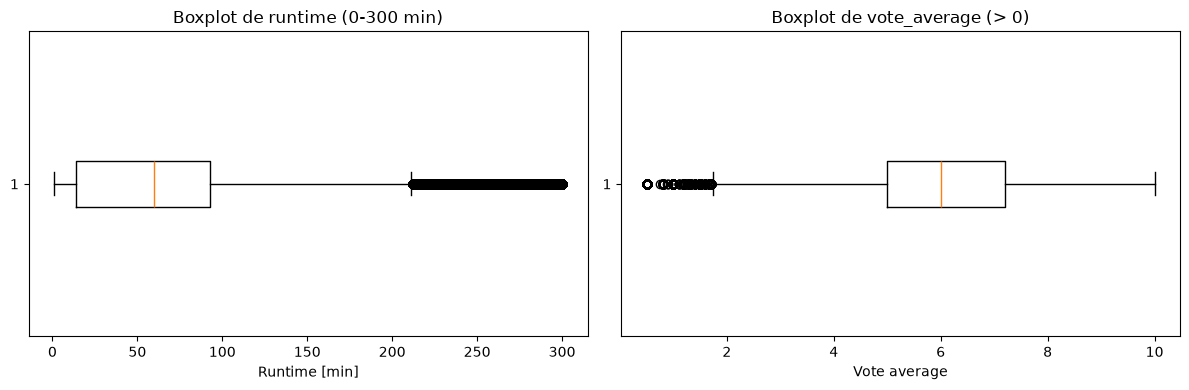

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Runtime: se restringe la visualización al rango principal
runtime_plot = df.loc[
    (df["runtime"] > 0) & (df["runtime"] <= 300),
    "runtime"
]

axes[0].boxplot(runtime_plot, orientation="horizontal")
axes[0].set_title("Boxplot de runtime (0-300 min)")
axes[0].set_xlabel("Runtime [min]")

# Vote average: se consideran valores mayores a cero
vote_plot = df.loc[
    df["vote_average"] > 0,
    "vote_average"
]

axes[1].boxplot(vote_plot, orientation="horizontal")
axes[1].set_title("Boxplot de vote_average (> 0)")
axes[1].set_xlabel("Vote average")

plt.tight_layout()
plt.show()

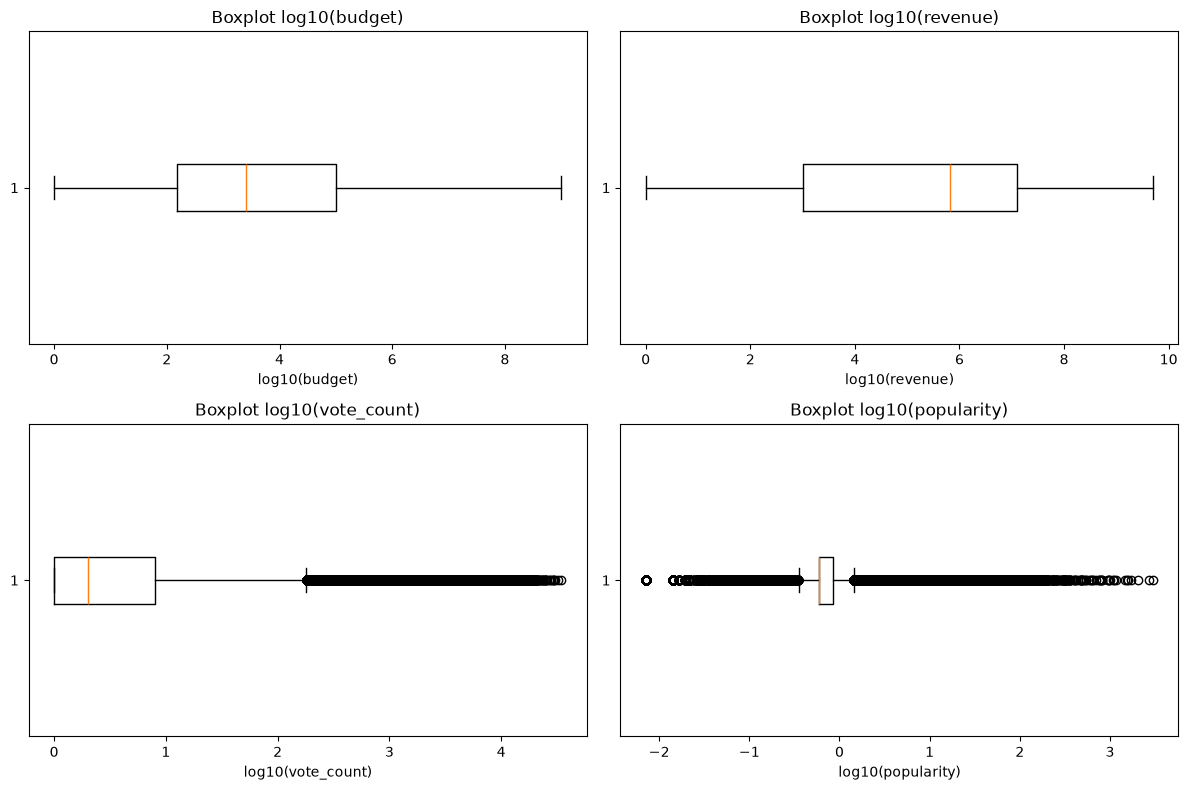

In [50]:
cols_log = ["budget", "revenue", "vote_count", "popularity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_log):
    values = df.loc[df[col] > 0, col]

    ax.boxplot(np.log10(values), orientation="horizontal")
    ax.set_title(f"Boxplot log10({col})")
    ax.set_xlabel(f"log10({col})")

plt.tight_layout()
plt.show()

In [51]:
variables_outliers = [
    "runtime",
    "vote_average",
    "budget",
    "revenue",
    "vote_count",
    "popularity"
]

outlier_summary = []

for col in variables_outliers:
    values = df.loc[df[col] > 0, col]

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((values < lower_bound) | (values > upper_bound)).sum()
    pct_outliers = 100 * n_outliers / len(values)

    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": n_outliers,
        "outliers_%": pct_outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,variable,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outliers_%
0,runtime,14.0,9.400000e+01,8.000000e+01,-1.060000e+02,2.140000e+02,12526,1.237763
1,vote_average,5.0,7.200000e+00,2.200000e+00,1.700000e+00,1.050000e+01,8008,2.223709
2,budget,150.0,1.000000e+05,9.985000e+04,-1.496250e+05,2.497750e+05,19221,22.229804
3,revenue,1000.0,1.263847e+07,1.263747e+07,-1.895520e+07,3.159467e+07,4211,16.762200
4,vote_count,1.0,8.000000e+00,7.000000e+00,-9.500000e+00,1.850000e+01,52059,14.444984
5,popularity,0.6,8.570000e-01,2.570000e-01,2.145001e-01,1.242500e+00,371480,30.658791


### Interpretación de los boxplots y criterio IQR

Los diagramas de caja confirman la presencia de valores alejados de los rangos centrales de varias variables. Sin embargo, la magnitud de estos valores atípicos depende fuertemente de la forma de cada distribución.

Para `runtime` y `vote_average`, el criterio basado en el rango intercuartílico identifica como atípico aproximadamente al 1,2 % y 2,2 % de los valores positivos, respectivamente. En estos casos, el método resulta relativamente selectivo.

En cambio, para `budget`, `revenue`, `vote_count` y especialmente `popularity`, el porcentaje de observaciones identificado como outlier es considerablemente mayor. Esto se debe a que estas variables presentan distribuciones fuertemente asimétricas y colas derechas extensas.

Por lo tanto, los valores identificados mediante el criterio IQR no serán eliminados automáticamente. Se distinguirán los valores claramente inconsistentes de aquellos que, aunque estadísticamente extremos, pueden corresponder a observaciones válidas del fenómeno analizado.

## 7. Análisis de variables no numéricas

La selección de columnas de tipo texto (`object`) incluye variables de distinta naturaleza, por lo que no resulta adecuado tratarlas a todas como variables categóricas.

A partir de su significado, pueden distinguirse:

- **Variables categóricas simples:** `status` y `original_language`.
- **Variables multietiqueta o con múltiples categorías por observación:** `genres`, `spoken_languages`, `production_countries`, `production_companies` y `keywords`.
- **Variables de texto libre:** `title`, `original_title`, `overview` y `tagline`.
- **Identificadores o metadatos:** `imdb_id`, `homepage`, `poster_path` y `backdrop_path`.

Esta distinción es relevante para el preprocesamiento, ya que cada grupo requiere un tratamiento diferente y algunas columnas podrían no resultar adecuadas como predictores en el problema de Machine Learning planteado.

### Cardinalidad y valores faltantes de las variables no numéricas

### Distribución de las variables categóricas simples

Dentro de las variables no numéricas, `status` y `original_language` pueden considerarse variables categóricas simples, ya que cada observación posee una única categoría.

A continuación se analiza la frecuencia de sus categorías para identificar cuáles predominan y evaluar posibles desbalances o categorías poco representadas.

In [53]:
categorical_simple = ["status", "original_language"]

for col in categorical_simple:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(20))


--- status ---
status
Released           1420795
In Production        25557
Post Production      16743
Planned              12486
Rumored                891
Canceled               379
Name: count, dtype: int64

--- original_language ---
original_language
en    810185
fr     85144
es     76388
ja     67729
de     65317
zh     46849
pt     45836
it     29511
ru     29201
ko     16121
cs     12849
nl     11519
ar     10708
sv     10397
tr     10248
hi      9161
pl      9068
xx      8136
tl      7558
id      6320
Name: count, dtype: int64


### Interpretación de las variables categóricas simples

La variable `status` se encuentra fuertemente concentrada en la categoría `Released`, mientras que categorías como `In Production`, `Post Production`, `Planned`, `Rumored` y `Canceled` representan una proporción mucho menor del dataset.

Esto indica un fuerte desbalance entre las categorías de `status`, aunque en este caso dicha distribución es coherente con la naturaleza del dataset, ya que la mayoría de las películas registradas corresponden a producciones ya estrenadas.

En el caso de `original_language`, se observa una mayor diversidad de categorías. Sin embargo, algunas lenguas concentran una proporción significativamente mayor de películas que otras.

### Análisis de variables multietiqueta

In [55]:
df[["genres", "spoken_languages", "production_countries", "production_companies", "keywords"]].head(10)

,genres,spoken_languages,production_countries,production_companies,keywords
0,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict...","rescue, mission, dream, airplane, paris, franc..."
1,"Adventure, Drama, Science Fiction",English,"United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc...","rescue, future, spacecraft, race against time,..."
2,"Drama, Action, Crime, Thriller","English, Mandarin","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel...","joker, sadism, chaos, secret identity, crime f..."
3,"Action, Adventure, Fantasy, Science Fiction","English, Spanish","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ...","future, society, culture clash, space travel, ..."
4,"Science Fiction, Action, Adventure","English, Hindi, Russian",United States of America,Marvel Studios,"new york city, superhero, shield, based on com..."
5,"Action, Adventure, Comedy",English,United States of America,"20th Century Fox, The Donners' Company, Genre ...","superhero, anti hero, mercenary, based on comi..."
6,"Adventure, Action, Science Fiction","English, Xhosa",United States of America,Marvel Studios,"sacrifice, magic, superhero, based on comic, s..."
7,Drama,English,United States of America,"Regency Enterprises, Fox 2000 Pictures, Taurus...","dual identity, rage and hate, based on novel o..."
8,"Action, Science Fiction, Adventure",English,United States of America,Marvel Studios,"spacecraft, based on comic, space, orphan, adv..."
9,"Thriller, Crime","English, Spanish, French",United States of America,"Miramax, A Band Apart, Jersey Films","drug dealer, boxer, massage, stolen money, bri..."


In [56]:
# Separar los géneros individuales y contar su frecuencia

genres_exploded = (
    df["genres"]
    .dropna()
    .str.split(", ")
    .explode()
)

genre_counts = genres_exploded.value_counts()

genre_counts

genres
Drama              268322
Documentary        203881
Comedy             163241
Animation           68958
Horror              66933
Romance             61403
Music               58320
Thriller            56837
Action              51577
Crime               38613
Family              32138
Fantasy             28516
Adventure           27810
TV Movie            26383
Science Fiction     26351
Mystery             25090
History             19417
War                 11902
Western              9617
Name: count, dtype: int64

In [57]:
genre_percentages = (
    genre_counts / df["genres"].notna().sum() * 100
)

genre_percentages

genres
Drama              32.810263
Documentary        24.930454
Comedy             19.961017
Animation           8.432145
Horror              8.184529
Romance             7.508324
Music               7.131337
Thriller            6.949996
Action              6.306806
Crime               4.721576
Family              3.929816
Fantasy             3.486920
Adventure           3.400591
TV Movie            3.226098
Science Fiction     3.222185
Mystery             3.067991
History             2.374300
War                 1.455370
Western             1.175961
Name: count, dtype: float64

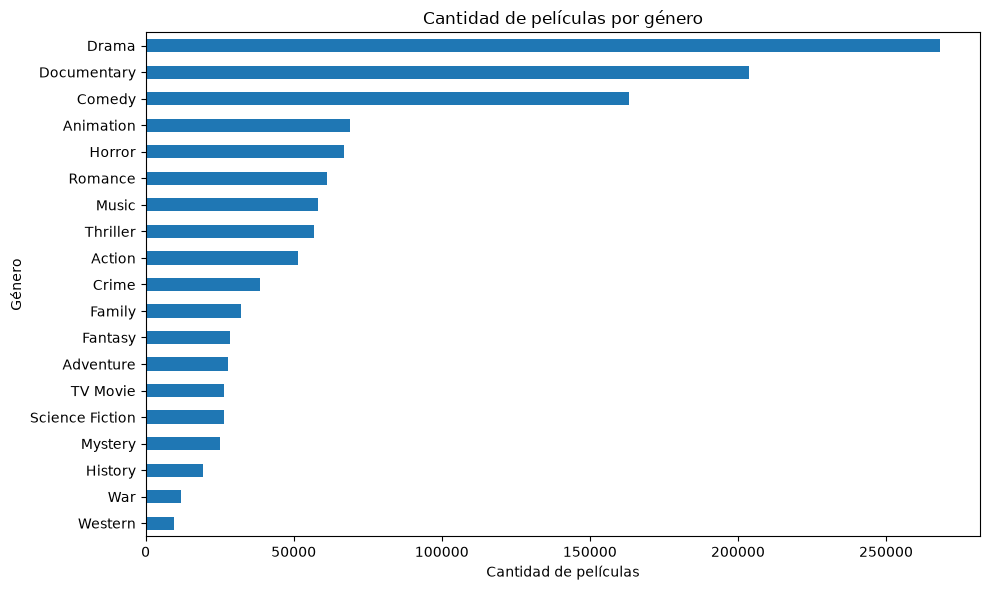

In [58]:
plt.figure(figsize=(10, 6))

genre_counts.sort_values().plot(kind="barh")

plt.title("Cantidad de películas por género")
plt.xlabel("Cantidad de películas")
plt.ylabel("Género")
plt.tight_layout()
plt.show()

### Interpretación de la distribución de géneros

La variable `genres` contiene múltiples categorías por película, por lo que fue necesario separar las etiquetas individuales antes de analizar su frecuencia.

Se observa que los géneros más frecuentes son `Drama`, `Documentary` y `Comedy`, con una presencia considerablemente superior al resto. En cambio, géneros como `War` y `Western` aparecen con mucha menor frecuencia.

Dado que una misma película puede pertenecer simultáneamente a varios géneros, las frecuencias no representan categorías mutuamente excluyentes y sus porcentajes acumulados pueden superar el 100 %.

Esta estructura multietiqueta sugiere que, en una etapa posterior de feature engineering, `genres` podría transformarse en variables binarias que indiquen la presencia o ausencia de cada género en una película.

### Idiomas y países de producción

Además de los géneros, se analizan las categorías individuales presentes en `spoken_languages` y `production_countries`.

Al igual que `genres`, ambas son variables multietiqueta, ya que una película puede contener más de un idioma hablado y estar asociada a más de un país de producción. Por este motivo, las categorías se separan antes de calcular sus frecuencias.

In [59]:
spoken_languages_exploded = (
    df["spoken_languages"]
    .dropna()
    .str.split(", ")
    .explode()
)

production_countries_exploded = (
    df["production_countries"]
    .dropna()
    .str.split(", ")
    .explode()
)

print("Idiomas más frecuentes:")
display(spoken_languages_exploded.value_counts().head(15))

print("\nPaíses de producción más frecuentes:")
display(production_countries_exploded.value_counts().head(15))

Idiomas más frecuentes:


spoken_languages
English        319172
French          58285
Spanish         55453
Japanese        55446
German          44451
No Language     36059
Portuguese      27658
Russian         24882
Italian         23055
Mandarin        21386
Korean          13002
Czech           12336
Arabic          11308
Hindi            9408
Swedish          8444
Name: count, dtype: int64


Países de producción más frecuentes:


production_countries
United States of America    219482
Japan                        54432
France                       52147
United Kingdom               49873
Germany                      48819
Canada                       27655
India                        24378
Brazil                       22282
Italy                        21436
Spain                        18213
Mexico                       14146
Russia                       12844
China                        11778
Soviet Union                 11389
South Korea                  11049
Name: count, dtype: int64

### Interpretación de idiomas y países de producción

Entre los idiomas hablados, `English` es claramente el más frecuente, seguido a considerable distancia por `French`, `Spanish`, `Japanese` y `German`. También aparece la categoría `No Language`, que representa producciones sin idioma hablado y debe distinguirse de un valor faltante.

En cuanto a los países de producción, `United States of America` presenta una frecuencia muy superior al resto. Luego aparecen `Japan`, `France`, `United Kingdom` y `Germany`, entre otros.

Al igual que en el caso de `genres`, estas frecuencias no corresponden a categorías mutuamente excluyentes, ya que una misma película puede estar asociada a múltiples idiomas y países de producción.

## 8. Análisis temporal de los estrenos

La variable `release_date` permite analizar la distribución temporal de las películas y evaluar posibles cambios en la cantidad de registros a lo largo de los años.

Además de su utilidad exploratoria, esta variable puede utilizarse posteriormente para generar nuevas features, como el año o la década de estreno.

### Validación de las fechas de estreno

La variable `release_date` contiene registros correspondientes tanto a películas ya estrenadas como a producciones con fechas de estreno futuras.

Dado que el dataset incluye películas en distintos estados de producción, una fecha futura no debe considerarse automáticamente un error. Por este motivo, se analiza la relación entre las fechas posteriores al año actual y el estado (`status`) de cada producción antes de decidir su tratamiento.

In [63]:
current_year = 2026

release_year = df["release_date"].dt.year

print("Películas con fecha válida:", release_year.notna().sum())
print("Películas sin fecha:", release_year.isna().sum())

print("\nAño mínimo:", int(release_year.min()))
print("Año máximo:", int(release_year.max()))

print(
    "\nPelículas con fecha posterior a 2026:",
    (release_year > current_year).sum()
)

Películas con fecha válida: 1133334
Películas sin fecha: 343517

Año mínimo: 1800
Año máximo: 2099

Películas con fecha posterior a 2026: 554


In [64]:
future_movies = df.loc[
    release_year > current_year,
    ["title", "status", "release_date"]
]

future_movies["status"].value_counts()

status
In Production      303
Planned            173
Released            30
Post Production     30
Rumored             17
Canceled             1
Name: count, dtype: int64

### Interpretación de las fechas futuras

Se identificaron 554 películas con fecha de estreno posterior a 2026.

La mayoría de estos registros se encuentran en estados compatibles con una fecha futura, principalmente `In Production`, `Planned` y `Post Production`. Por lo tanto, estas fechas no se consideran automáticamente errores, sino observaciones coherentes con producciones todavía no estrenadas.

Sin embargo, se detectaron algunos casos clasificados como `Released` con fechas posteriores a 2026. Estos registros deberán revisarse durante la etapa de limpieza para determinar si corresponden a inconsistencias o a situaciones particulares del registro.

### Distribución temporal de los estrenos

Para analizar la evolución histórica del número de películas registradas, se consideran las observaciones con año de estreno válido hasta 2026. Las fechas futuras se excluyen únicamente de esta visualización para evitar distorsionar la escala temporal.

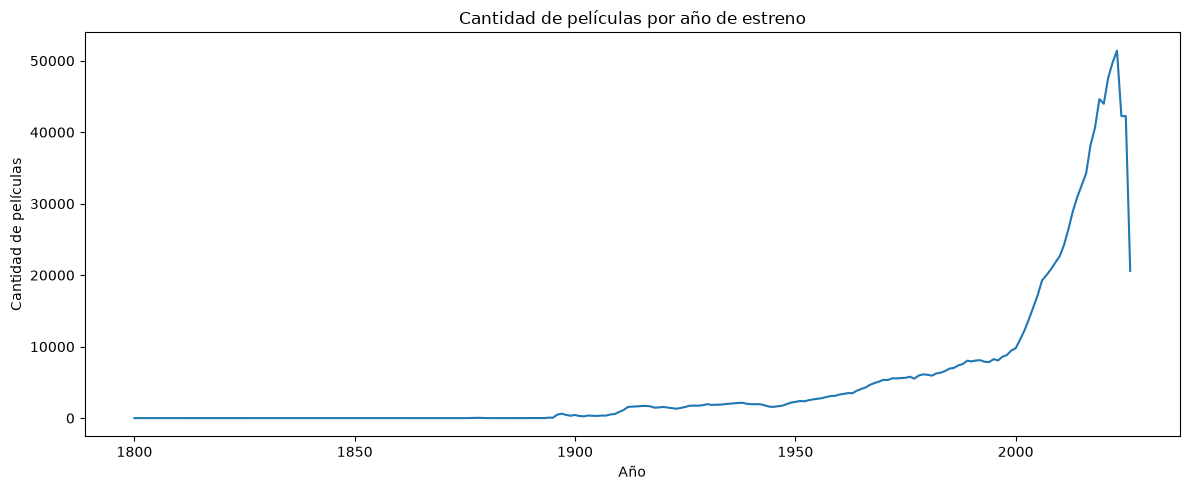

In [65]:
movies_per_year = (
    release_year[
        release_year.notna() &
        (release_year <= 2026)
    ]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(movies_per_year.index, movies_per_year.values)

plt.title("Cantidad de películas por año de estreno")
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.tight_layout()
plt.show()

### Acercamiento a los años recientes

El gráfico histórico muestra un fuerte incremento en la cantidad de películas registradas durante las últimas décadas. Para observar con mayor detalle este comportamiento reciente, se realiza un acercamiento al período comprendido entre 2000 y 2026.

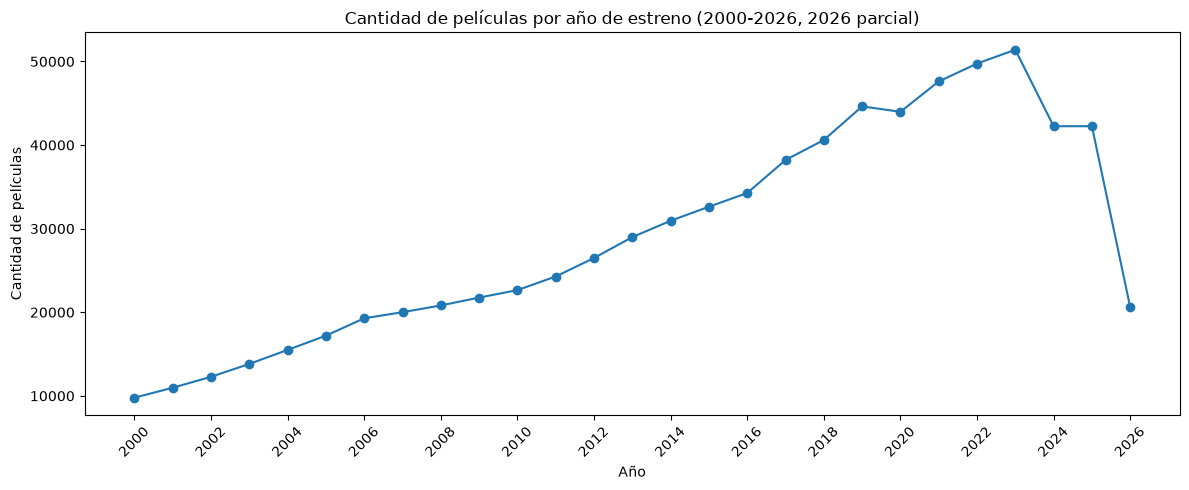

In [67]:
recent_movies_per_year = movies_per_year[
    movies_per_year.index >= 2000
]

plt.figure(figsize=(12, 5))
plt.plot(
    recent_movies_per_year.index,
    recent_movies_per_year.values,
    marker="o"
)

plt.title("Cantidad de películas por año de estreno (2000-2026, 2026 parcial)")
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.xticks(range(2000, 2027, 2), rotation=45)
plt.tight_layout()
plt.show()

### Interpretación de la evolución temporal reciente

Entre 2000 y 2023 se observa una tendencia general creciente en la cantidad de películas registradas por año, pasando de aproximadamente 10 mil registros anuales a más de 50 mil.

A partir de 2024 se observa una disminución en la cantidad de registros, que se vuelve especialmente marcada en 2026. Esta caída no debe interpretarse necesariamente como una reducción real de la producción cinematográfica, ya que puede estar asociada a que los años más recientes se encuentren incompletos o a retrasos en la incorporación de películas al dataset.

Por este motivo, los años más recientes deberán interpretarse con cautela en cualquier análisis temporal posterior.

## 9. Análisis del mecanismo de valores faltantes

Además de cuantificar los valores ausentes, resulta relevante analizar el posible mecanismo que origina su ausencia.

Se consideran las siguientes categorías:

- **MCAR (Missing Completely At Random):** la ausencia no depende de ninguna variable observada ni del propio valor faltante.
- **MAR (Missing At Random):** la probabilidad de ausencia puede estar relacionada con otras variables observadas.
- **MNAR (Missing Not At Random):** la ausencia puede estar relacionada con el propio valor no observado.
- **Faltante estructural o por diseño:** la ausencia es consecuencia de la naturaleza del registro y no de una pérdida aleatoria de información.

Dado que el mecanismo de ausencia no puede determinarse de manera concluyente únicamente a partir del dataset, las clasificaciones siguientes se plantean como hipótesis basadas en la estructura y el significado de las variables.

In [70]:
missing_analysis = pd.DataFrame({
    "budget_missing_like": df["budget"].eq(0),
    "revenue_missing_like": df["revenue"].eq(0),
    "release_date_missing": df["release_date"].isna(),
    "overview_missing": df["overview"].isna(),
    "imdb_id_missing": df["imdb_id"].isna()
})

missing_analysis.mean() * 100

budget_missing_like     94.145313
revenue_missing_like    98.298881
release_date_missing    23.260099
overview_missing        23.207825
imdb_id_missing         53.880046
dtype: float64

### Relación entre valores faltantes y variables observadas

Para evaluar si los valores faltantes podrían considerarse completamente aleatorios (MCAR), se analiza si su presencia está asociada con otras variables observadas del dataset.

Si la proporción de datos faltantes cambia sistemáticamente según características como el estado de producción, la popularidad o la cantidad de votos, la hipótesis de MCAR resulta menos plausible y podría existir un mecanismo MAR o estructural.

In [71]:
release_missing_by_status = (
    df.groupby("status")["release_date"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

release_missing_by_status

status
Canceled           95.250660
Rumored            94.163861
Planned            84.670831
Post Production    67.419220
In Production      34.268498
Released           21.938351
Name: release_date, dtype: float64

In [72]:
economic_missing_comparison = pd.DataFrame({
    "budget = 0": df.loc[df["budget"] == 0,
                         ["popularity", "vote_count"]].median(),
    
    "budget > 0": df.loc[df["budget"] > 0,
                         ["popularity", "vote_count"]].median(),
    
    "revenue = 0": df.loc[df["revenue"] == 0,
                          ["popularity", "vote_count"]].median(),
    
    "revenue > 0": df.loc[df["revenue"] > 0,
                          ["popularity", "vote_count"]].median()
})

economic_missing_comparison

,budget = 0,budget > 0,revenue = 0,revenue > 0
popularity,0.6,0.6,0.6,3.0575
vote_count,0.0,0.0,0.0,17.0000


### Interpretación del mecanismo de ausencia

El análisis muestra que el mecanismo de ausencia no es necesariamente el mismo para todas las variables.

En `release_date`, la proporción de valores faltantes depende fuertemente del estado de producción. Mientras que aproximadamente el 22 % de las películas clasificadas como `Released` no posee fecha de estreno, esta proporción supera el 84 % en `Planned` y el 94 % en `Rumored` y `Canceled`. Esto permite descartar razonablemente un mecanismo completamente aleatorio (MCAR). En producciones todavía no estrenadas, canceladas o solamente anunciadas, parte de la ausencia puede considerarse estructural, ya que la fecha de estreno puede no estar definida.

Para `revenue`, las películas con valores positivos presentan mayores valores medianos de `popularity` y `vote_count` que aquellas con `revenue = 0`. Esto sugiere que la disponibilidad de información sobre ingresos se encuentra asociada con características observables de las películas, por lo que un mecanismo MCAR también resulta poco probable y un mecanismo MAR constituye una hipótesis plausible.

En el caso de `budget`, las variables observadas analizadas (`popularity` y `vote_count`) no muestran diferencias relevantes entre películas con presupuesto igual a cero y aquellas con presupuesto positivo. Por lo tanto, este análisis no proporciona evidencia suficiente para determinar el mecanismo de ausencia.

Finalmente, no es posible confirmar un mecanismo MNAR únicamente a partir de los valores observados, ya que esto requeriría demostrar que la probabilidad de ausencia depende del propio valor no observado.

### Análisis de otros valores faltantes

Se analiza también la ausencia de `overview` e `imdb_id` para evaluar si su disponibilidad presenta diferencias según características observables de las películas.

In [73]:
other_missing_comparison = pd.DataFrame({
    "overview presente": df.loc[
        df["overview"].notna(),
        ["popularity", "vote_count"]
    ].median(),

    "overview faltante": df.loc[
        df["overview"].isna(),
        ["popularity", "vote_count"]
    ].median(),

    "imdb_id presente": df.loc[
        df["imdb_id"].notna(),
        ["popularity", "vote_count"]
    ].median(),

    "imdb_id faltante": df.loc[
        df["imdb_id"].isna(),
        ["popularity", "vote_count"]
    ].median()
})

other_missing_comparison

,overview presente,overview faltante,imdb_id presente,imdb_id faltante
popularity,0.6,0.6,0.6,0.6
vote_count,0.0,0.0,0.0,0.0


In [74]:
missing_by_status = pd.DataFrame({
    "release_date_%": df.groupby("status")["release_date"]
        .apply(lambda x: x.isna().mean() * 100),

    "overview_%": df.groupby("status")["overview"]
        .apply(lambda x: x.isna().mean() * 100),

    "imdb_id_%": df.groupby("status")["imdb_id"]
        .apply(lambda x: x.isna().mean() * 100)
}).round(2)

missing_by_status

,release_date_%,overview_%,imdb_id_%
status,,,
Canceled,95.25,41.42,75.46
In Production,34.27,22.75,78.00
Planned,84.67,24.76,71.93
Post Production,67.42,24.15,63.48
Released,21.94,23.18,53.15
Rumored,94.16,31.09,83.61


### Síntesis del análisis de valores faltantes

A partir de los análisis realizados, se pueden plantear las siguientes hipótesis sobre el mecanismo de ausencia de las principales variables estudiadas:

| Variable | Mecanismo probable | Justificación |
|---|---|---|
| `release_date` | Estructural / MAR | La proporción de faltantes cambia fuertemente según `status`, especialmente en películas `Planned`, `Rumored` o `Canceled`. |
| `revenue` | MAR plausible | Los registros con ingresos positivos presentan mayores valores de `popularity` y `vote_count`, lo que indica asociación con variables observadas. |
| `budget` | Indeterminado | No se observaron diferencias claras en `popularity` ni `vote_count` entre registros con presupuesto igual a cero y positivo. |
| `overview` | MAR plausible / indeterminado | La ausencia varía según `status`, aunque no se observaron diferencias en las medianas de `popularity` y `vote_count`. |
| `imdb_id` | MAR plausible | La proporción de faltantes varía considerablemente según `status`, por lo que la ausencia no parece completamente aleatoria. |

No se encontró evidencia suficiente para afirmar que alguna de estas variables siga un mecanismo MNAR. Dicha clasificación requeriría demostrar que la probabilidad de ausencia depende del propio valor no observado, algo que no puede verificarse directamente con la información disponible.

En consecuencia, no resulta adecuado asumir que los valores faltantes son completamente aleatorios. El tratamiento posterior deberá considerar tanto la naturaleza de cada variable como el posible mecanismo que genera su ausencia.

## 10. Relaciones entre variables numéricas

Luego de analizar las variables de manera individual, se estudian relaciones entre algunas de las principales variables numéricas del dataset.

El objetivo es identificar asociaciones relevantes, posibles redundancias entre features y relaciones que puedan resultar útiles para definir posteriormente un problema de Machine Learning supervisado.

Dado que varias variables presentan distribuciones fuertemente asimétricas y una elevada proporción de valores iguales a cero, algunas relaciones se analizarán sobre subconjuntos de observaciones válidas y mediante transformaciones logarítmicas únicamente con fines de visualización.

In [68]:
sample_df = df.sample(
    n=min(100_000, len(df)),
    random_state=42
)

sample_df.shape

(100000, 24)

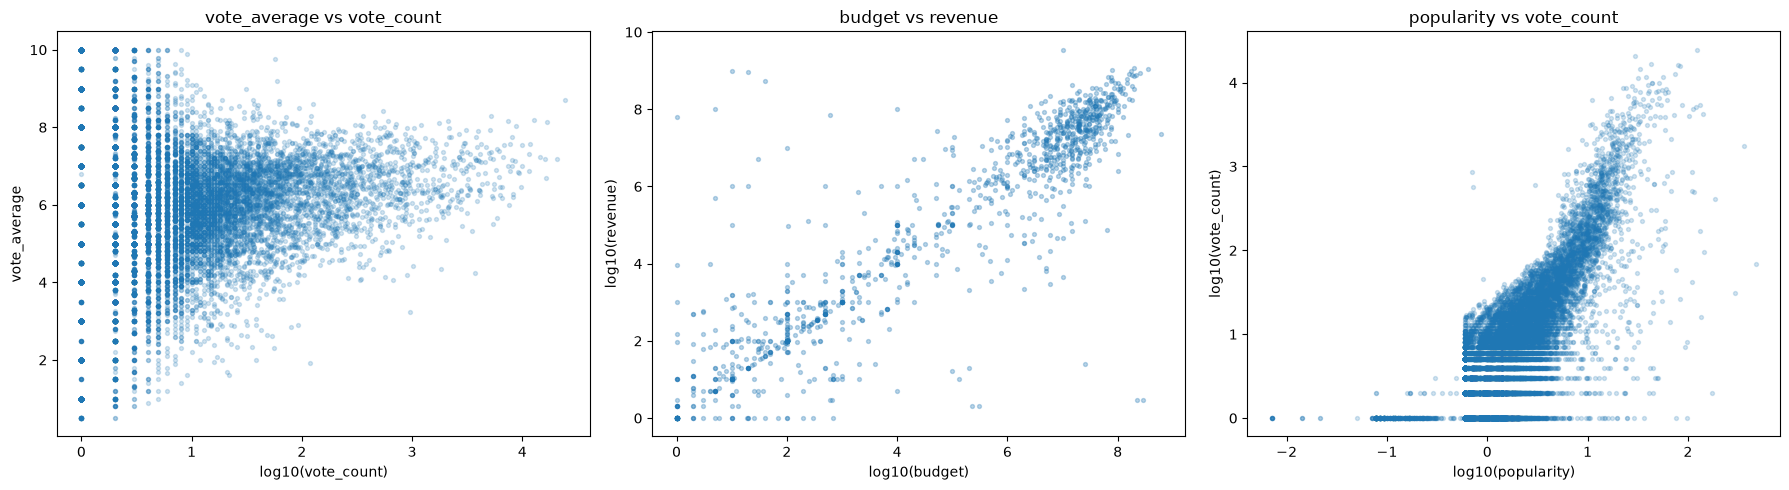

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Vote average vs vote count
mask_vote = (
    (sample_df["vote_count"] > 0) &
    (sample_df["vote_average"] > 0)
)

axes[0].scatter(
    np.log10(sample_df.loc[mask_vote, "vote_count"]),
    sample_df.loc[mask_vote, "vote_average"],
    alpha=0.2,
    s=8
)
axes[0].set_xlabel("log10(vote_count)")
axes[0].set_ylabel("vote_average")
axes[0].set_title("vote_average vs vote_count")


# Budget vs revenue
mask_money = (
    (sample_df["budget"] > 0) &
    (sample_df["revenue"] > 0)
)

axes[1].scatter(
    np.log10(sample_df.loc[mask_money, "budget"]),
    np.log10(sample_df.loc[mask_money, "revenue"]),
    alpha=0.3,
    s=8
)
axes[1].set_xlabel("log10(budget)")
axes[1].set_ylabel("log10(revenue)")
axes[1].set_title("budget vs revenue")


# Popularity vs vote count
mask_pop = (
    (sample_df["popularity"] > 0) &
    (sample_df["vote_count"] > 0)
)

axes[2].scatter(
    np.log10(sample_df.loc[mask_pop, "popularity"]),
    np.log10(sample_df.loc[mask_pop, "vote_count"]),
    alpha=0.2,
    s=8
)
axes[2].set_xlabel("log10(popularity)")
axes[2].set_ylabel("log10(vote_count)")
axes[2].set_title("popularity vs vote_count")

plt.tight_layout()
plt.show()

### Interpretación de las relaciones entre variables

Los diagramas de dispersión muestran comportamientos diferentes entre las variables analizadas.

En la relación entre `vote_average` y `vote_count` no se observa una relación lineal fuerte. Sin embargo, para películas con pocos votos existe una dispersión mucho mayor en la puntuación promedio, incluyendo valores muy altos y muy bajos. A medida que aumenta `vote_count`, los valores de `vote_average` tienden a concentrarse en un rango más acotado, aproximadamente alrededor de puntuaciones intermedias. Esto es coherente con una mayor estabilidad del promedio cuando se dispone de más votos.

Entre `budget` y `revenue` se observa una asociación positiva clara en escala logarítmica: las películas con mayores presupuestos tienden, en general, a presentar mayores ingresos. No obstante, existe dispersión y algunos casos extremos, por lo que la relación no es determinística.

La relación entre `popularity` y `vote_count` presenta una asociación positiva marcada: las películas con mayor popularidad tienden, en general, a acumular una mayor cantidad de votos. Esta relación deberá interpretarse con cautela, ya que popularity es una métrica compuesta de TMDB y la cantidad de votos constituye una de las señales asociadas a su cálculo. Por lo tanto, parte de la asociación observada puede estar vinculada con la propia construcción de la variable, además de reflejar un comportamiento real de las películas.

### Correlación entre variables numéricas

Para complementar los diagramas de dispersión se calcula la correlación de Spearman entre las principales variables numéricas.

Se utiliza Spearman en lugar de Pearson debido a la fuerte asimetría de varias variables, la presencia de valores extremos y la posibilidad de relaciones monotónicas no estrictamente lineales.

In [75]:
corr_cols = [
    "vote_average",
    "vote_count",
    "runtime",
    "budget",
    "revenue",
    "popularity"
]

corr_matrix = df[corr_cols].corr(method="spearman")

corr_matrix

,vote_average,vote_count,runtime,budget,revenue,popularity
vote_average,1.000000,0.970282,0.305751,0.065972,0.141744,0.502244
vote_count,0.970282,1.000000,0.334491,0.074410,0.168566,0.547464
runtime,0.305751,0.334491,1.000000,0.027450,0.092052,0.314458
budget,0.065972,0.074410,0.027450,1.000000,0.377484,0.027835
revenue,0.141744,0.168566,0.092052,0.377484,1.000000,0.115880
popularity,0.502244,0.547464,0.314458,0.027835,0.115880,1.000000


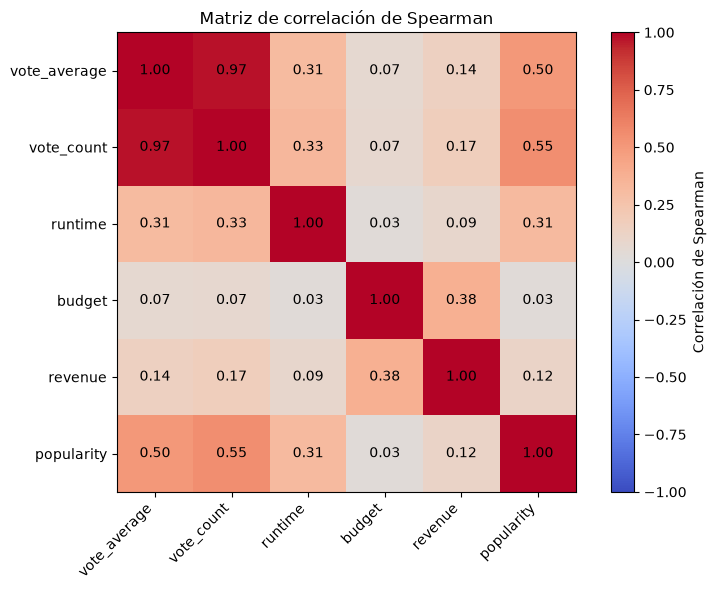

In [81]:
plt.figure(figsize=(8, 6))

plt.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(label="Correlación de Spearman")

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

# Mostrar coeficientes dentro de cada celda
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr_matrix.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

### Interpretación preliminar de la matriz de correlación

La matriz de Spearman muestra asociaciones elevadas entre algunas variables. En particular, `vote_average` y `vote_count` presentan una correlación muy alta (ρ ≈ 0,97).

Sin embargo, esta relación debe interpretarse con cautela, ya que ambas variables contienen una elevada proporción de valores iguales a cero y estos ceros aparecen frecuentemente de manera simultánea. Esta característica puede aumentar artificialmente la correlación calculada sobre el dataset completo.

De forma similar, las correlaciones que involucran `budget` y `revenue` pueden verse afectadas por la gran cantidad de valores iguales a cero, que podrían representar información no reportada.

Por este motivo, se realizará un análisis complementario considerando únicamente observaciones con valores positivos en las variables involucradas.

In [78]:
# vote_average vs vote_count, considerando películas con votos
vote_valid = df.loc[
    (df["vote_count"] > 0) &
    (df["vote_average"] > 0),
    ["vote_average", "vote_count"]
]

vote_corr = vote_valid.corr(method="spearman").iloc[0, 1]

# budget vs revenue, considerando información económica positiva
money_valid = df.loc[
    (df["budget"] > 0) &
    (df["revenue"] > 0),
    ["budget", "revenue"]
]

money_corr = money_valid.corr(method="spearman").iloc[0, 1]

# popularity vs vote_count, considerando valores positivos
pop_valid = df.loc[
    (df["popularity"] > 0) &
    (df["vote_count"] > 0),
    ["popularity", "vote_count"]
]

pop_corr = pop_valid.corr(method="spearman").iloc[0, 1]

print(f"vote_average vs vote_count: {vote_corr:.3f}")
print(f"budget vs revenue: {money_corr:.3f}")
print(f"popularity vs vote_count: {pop_corr:.3f}")

vote_average vs vote_count: -0.109
budget vs revenue: 0.895
popularity vs vote_count: 0.691


### Correlaciones considerando observaciones válidas

Al recalcular las correlaciones excluyendo los valores iguales a cero en las variables involucradas, los resultados cambian considerablemente.

La correlación entre `vote_average` y `vote_count` disminuye de aproximadamente 0,97 a -0,11. Esto confirma que la correlación extremadamente elevada observada inicialmente estaba fuertemente influida por la gran cantidad de ceros simultáneos presentes en ambas variables. Entre películas que efectivamente poseen votos y puntuaciones positivas, la asociación monotónica entre ambas variables es muy débil.

En cambio, `budget` y `revenue` presentan una correlación de Spearman elevada (ρ ≈ 0,90) cuando se consideran únicamente películas con valores económicos positivos. Esto indica una fuerte asociación monotónica: en general, las películas con mayores presupuestos tienden también a presentar mayores ingresos.

Finalmente, `popularity` y `vote_count` mantienen una asociación positiva considerable (ρ ≈ 0,69), lo que indica que las películas con mayor popularidad tienden a acumular una mayor cantidad de votos.

Estos resultados muestran la importancia de considerar la calidad y estructura de los datos antes de interpretar directamente una matriz de correlación.

In [79]:
corr_cols = [
    "vote_average",
    "vote_count",
    "runtime",
    "budget",
    "revenue",
    "popularity"
]

corr_positive = pd.DataFrame(
    index=corr_cols,
    columns=corr_cols,
    dtype=float
)

for col1 in corr_cols:
    for col2 in corr_cols:

        mask = (
            (df[col1] > 0) &
            (df[col2] > 0)
        )

        corr_positive.loc[col1, col2] = (
            df.loc[mask, [col1, col2]]
            .corr(method="spearman")
            .iloc[0, 1]
        )

corr_positive

,vote_average,vote_count,runtime,budget,revenue,popularity
vote_average,1.000000,-0.109398,0.045077,-0.285952,0.002344,-0.083177
vote_count,-0.109398,1.000000,0.249739,0.818309,0.749342,0.691033
runtime,0.045077,0.249739,1.000000,0.668689,0.525039,0.376276
budget,-0.285952,0.818309,0.668689,1.000000,0.894816,0.592355
revenue,0.002344,0.749342,0.525039,0.894816,1.000000,0.779277
popularity,-0.083177,0.691033,0.376276,0.592355,0.779277,1.000000


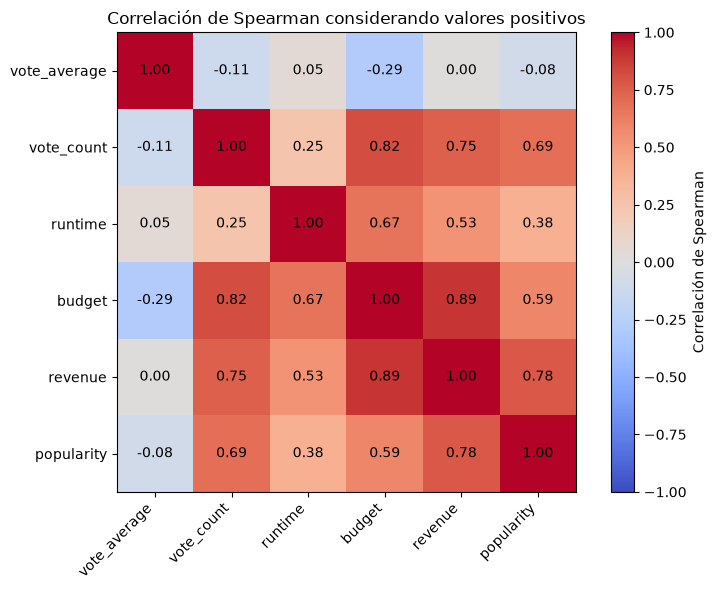

In [80]:
plt.figure(figsize=(8, 6))

plt.imshow(
    corr_positive.astype(float),
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(label="Correlación de Spearman")

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

# Mostrar el coeficiente dentro de cada celda
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr_positive.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlación de Spearman considerando valores positivos")
plt.tight_layout()
plt.show()

## 11. Planteamiento del problema de Machine Learning

In [85]:
target_candidates = pd.DataFrame({
    "Target": [
        "revenue",
        "vote_average",
        "popularity"
    ],
    "Registros totales": [
        len(df),
        len(df),
        len(df)
    ],
    "Registros según criterio": [
        (df["revenue"] > 0).sum(),
        ((df["vote_average"] > 0) & (df["vote_count"] > 0)).sum(),
        df["popularity"].notna().sum()
    ]
})

target_candidates["% según criterio"] = (
    target_candidates["Registros según criterio"] /
    target_candidates["Registros totales"] * 100
)

target_candidates

,Target,Registros totales,Registros según criterio,% según criterio
0,revenue,1476851,25122,1.701052
1,vote_average,1476851,359531,24.344433
2,popularity,1476851,1476851,100.000000


A partir del análisis exploratorio realizado se plantea un problema de regresión, cuyo objetivo será predecir la puntuación promedio de una película (`vote_average`) a partir de sus características disponibles.

Se evaluaron también `revenue` y `popularity` como posibles variables objetivo. `Revenue` presenta valores positivos únicamente para una proporción muy reducida del dataset, lo que implicaría trabajar con una muestra considerablemente menor. Por su parte, `popularity`, aunque se encuentra disponible para prácticamente todos los registros, corresponde a una métrica compuesta propia de TMDB y presenta una distribución con fuertes concentraciones en determinados valores, lo que dificulta su interpretación como una característica objetiva de la película.

Por estas razones se selecciona `vote_average` como variable objetivo. Sin embargo, una puntuación promedio basada en muy pocos votos puede resultar poco representativa. Por lo tanto, antes de preparar el dataset se evaluará un umbral mínimo de `vote_count`, buscando un compromiso entre la confiabilidad de la puntuación y la cantidad de observaciones conservadas. 

In [86]:
vote_thresholds = [1, 5, 10, 20, 50, 100]

threshold_analysis = []

for threshold in vote_thresholds:
    mask = (
        (df["vote_average"] > 0) &
        (df["vote_count"] >= threshold)
    )

    threshold_analysis.append({
        "vote_count mínimo": threshold,
        "Registros": mask.sum(),
        "% del dataset": mask.mean() * 100
    })

threshold_analysis = pd.DataFrame(threshold_analysis)
threshold_analysis

,vote_count mínimo,Registros,% del dataset
0,1,359531,24.344433
1,5,125866,8.522593
2,10,78852,5.339198
3,20,50430,3.414698
4,50,27981,1.894639
5,100,18191,1.231742


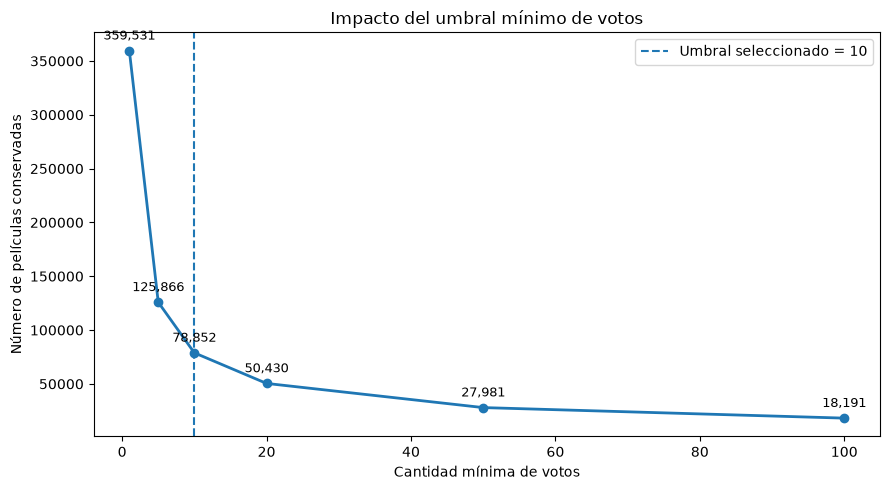

In [130]:
threshold_plot = []

for threshold in vote_thresholds:
    mask = (
        (df["vote_count"] >= threshold) &
        (df["vote_average"] > 0)
    )

    threshold_plot.append({
        "vote_count_min": threshold,
        "n_movies": mask.sum()
    })

threshold_plot = pd.DataFrame(threshold_plot)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    threshold_plot["vote_count_min"],
    threshold_plot["n_movies"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    threshold_plot["vote_count_min"],
    threshold_plot["n_movies"]
):
    ax.annotate(
        f"{y:,}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

ax.axvline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="Umbral seleccionado = 10"
)

ax.set_xlabel("Cantidad mínima de votos")
ax.set_ylabel("Número de películas conservadas")
ax.set_title("Impacto del umbral mínimo de votos")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "vote_count_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Selección del umbral mínimo de votos

La cantidad de observaciones disponibles disminuye rápidamente al aumentar el umbral mínimo de `vote_count`.

Se selecciona un umbral de **10 votos** como compromiso entre la representatividad de `vote_average` y la cantidad de datos disponibles. De esta manera se evitan puntuaciones basadas en una cantidad extremadamente reducida de votos, manteniendo aproximadamente 78.852 películas para el análisis posterior.

Por lo tanto, el problema de Machine Learning planteado será un problema de **regresión**, utilizando `vote_average` como variable objetivo y considerando únicamente películas con `vote_count >= 10`.

In [129]:
zero_rating_check = (
    (df["vote_count"] >= 10) &
    (df["vote_average"] == 0)
)

n_zero_rating = zero_rating_check.sum()

print(
    "Películas con al menos 10 votos y vote_average = 0:",
    f"{n_zero_rating:,}"
)

print(
    "Porcentaje dentro de las películas con al menos 10 votos:",
    f"{n_zero_rating / (df['vote_count'] >= 10).sum() * 100:.3f}%"
)

Películas con al menos 10 votos y vote_average = 0: 0
Porcentaje dentro de las películas con al menos 10 votos: 0.000%


El chequeo confirma que no existen películas con al menos 10 votos y `vote_average = 0`.

Por lo tanto, una vez aplicado el criterio `vote_count >= 10`, la condición `vote_average > 0` no elimina observaciones adicionales. Esto refuerza la interpretación de que los valores iguales a cero observados previamente corresponden principalmente a películas sin una cantidad suficiente de votos para construir una puntuación promedio representativa.

## 12. Preparación del dataset para Machine Learning

Una vez definido el problema de regresión y seleccionada `vote_average` como variable objetivo, se prepara el conjunto de datos que será utilizado en las etapas posteriores.

Se consideran únicamente películas:

- con estado `Released`;
- con `vote_average > 0`;
- con al menos 10 votos (`vote_count >= 10`).

La restricción a películas estrenadas permite trabajar con observaciones para las cuales la puntuación corresponde a una producción efectivamente disponible para los usuarios.

Como predictores se utilizarán principalmente características propias de la película, tales como duración, presupuesto, idioma original, géneros, fecha de estreno y algunas características derivadas de las variables multietiqueta.

Se excluyen como predictores `vote_count`, `popularity` y `revenue`. Las dos primeras contienen información asociada a la interacción posterior de los usuarios con la película, mientras que `revenue` corresponde a un resultado posterior al estreno y presenta además una proporción muy elevada de valores iguales a cero.

También se excluyen identificadores, títulos, URLs, rutas de imágenes y campos de texto libre, debido a que su tratamiento requeriría técnicas específicas de procesamiento de texto que exceden el alcance de este trabajo.

In [88]:
# Selección inicial de observaciones para el problema de regresión

model_mask = (
    (df["status"] == "Released") &
    (df["vote_average"] > 0) &
    (df["vote_count"] >= 10)
)

model_columns = [
    "id",
    "vote_average",
    "vote_count",
    "runtime",
    "budget",
    "adult",
    "original_language",
    "genres",
    "spoken_languages",
    "production_countries",
    "production_companies",
    "release_date"
]

df_model = df.loc[model_mask, model_columns].copy()

print(f"Observaciones antes de eliminar IDs duplicados: {len(df_model):,}")
print(f"IDs duplicados: {df_model['id'].duplicated().sum():,}")

Observaciones antes de eliminar IDs duplicados: 78,852
IDs duplicados: 0


### Feature engineering

A partir de algunas variables originales se generan nuevas características que puedan resultar más adecuadas para el análisis.

De `release_date` se extrae el año de estreno y se genera también la década de estreno como variable discretizada.

Las variables multietiqueta permiten además obtener información sobre la cantidad de géneros, idiomas hablados, países de producción y compañías productoras asociadas a cada película.

Finalmente, se genera una variable binaria que indica si el presupuesto se encuentra informado, ya que durante el EDA se observó una proporción elevada de valores iguales a cero en `budget`.

In [91]:
# Año y década de estreno
df_model["release_year"] = df_model["release_date"].dt.year

df_model["release_decade"] = (
    (df_model["release_year"] // 10) * 10
)

# Función para contar elementos en variables multietiqueta
def count_multilabel(series):
    return (
        series
        .fillna("")
        .apply(lambda x: 0 if x == "" else len(x.split(", ")))
    )

df_model["n_genres"] = count_multilabel(df_model["genres"])
df_model["n_spoken_languages"] = count_multilabel(df_model["spoken_languages"])
df_model["n_production_countries"] = count_multilabel(df_model["production_countries"])
df_model["n_production_companies"] = count_multilabel(df_model["production_companies"])

# Indicador de disponibilidad del presupuesto
df_model["budget_reported"] = (df_model["budget"] > 0).astype(int)

df_model.head()

,id,vote_average,vote_count,runtime,budget,adult,original_language,genres,spoken_languages,production_countries,production_companies,release_date,release_year,release_decade,n_genres,n_spoken_languages,n_production_countries,n_production_companies,budget_reported
0,27205,8.364,34495,148,160000000,False,en,"Action, Science Fiction, Adventure","English, French, Japanese, Swahili","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,2010.0,2010.0,3,4,2,3,1
1,157336,8.417,32571,169,165000000,False,en,"Adventure, Drama, Science Fiction",English,"United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc...",2014-11-05,2014.0,2010.0,3,1,2,3,1
2,155,8.512,30619,152,185000000,False,en,"Drama, Action, Crime, Thriller","English, Mandarin","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel...",2008-07-16,2008.0,2000.0,4,2,2,5,1
3,19995,7.573,29815,162,237000000,False,en,"Action, Adventure, Fantasy, Science Fiction","English, Spanish","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ...",2009-12-15,2009.0,2000.0,4,2,2,4,1
4,24428,7.710,29166,143,220000000,False,en,"Science Fiction, Action, Adventure","English, Hindi, Russian",United States of America,Marvel Studios,2012-04-25,2012.0,2010.0,3,3,1,1,1


In [92]:
model_summary = pd.DataFrame({
    "dtype": df_model.dtypes.astype(str),
    "n_missing": df_model.isna().sum(),
    "missing_%": df_model.isna().mean() * 100,
    "n_unique": df_model.nunique()
})

model_summary.round(2)

,dtype,n_missing,missing_%,n_unique
id,int32,0,0.00,78852
vote_average,float32,0,0.00,4959
vote_count,int32,0,0.00,3588
runtime,int32,0,0.00,339
budget,int64,0,0.00,2299
adult,bool,0,0.00,2
original_language,str,0,0.00,113
genres,str,910,1.15,6298
spoken_languages,str,1759,2.23,3265
production_countries,str,3626,4.60,3745


In [93]:
print(f"Dimensiones de df_model: {df_model.shape}")

display(
    df_model[
        [
            "vote_average",
            "vote_count",
            "runtime",
            "budget",
            "release_year",
            "n_genres",
            "n_spoken_languages",
            "n_production_countries",
            "n_production_companies"
        ]
    ].describe().T
)

Dimensiones de df_model: (78852, 19)


,count,mean,std,min,25%,50%,75%,max
vote_average,78852.0,6.133315e+00,1.028264e+00,1.179,5.5,6.2,6.833,10.0
vote_count,78852.0,2.631398e+02,1.182471e+03,10.000,15.0,29.0,88.000,34495.0
runtime,78852.0,9.088754e+01,3.638817e+01,0.000,84.0,94.0,106.000,960.0
budget,78852.0,3.354124e+06,1.589699e+07,0.000,0.0,0.0,0.000,460000000.0
release_year,78814.0,1.997002e+03,2.547980e+01,1874.000,1985.0,2007.0,2016.000,2025.0
n_genres,78852.0,2.086567e+00,1.042995e+00,0.000,1.0,2.0,3.000,9.0
n_spoken_languages,78852.0,1.241693e+00,7.075936e-01,0.000,1.0,1.0,1.000,19.0
n_production_countries,78852.0,1.208276e+00,7.273090e-01,0.000,1.0,1.0,1.000,26.0
n_production_companies,78852.0,2.030982e+00,1.894576e+00,0.000,1.0,2.0,3.000,30.0


## 13. Limpieza y definición de variables para el modelo

A partir del análisis del subconjunto seleccionado se toman las siguientes decisiones de preparación:

- Los registros sin fecha de estreno representan una proporción despreciable del conjunto de datos (0,05 %), por lo que se eliminan.
- Los valores de `runtime = 0` no representan una duración válida y se consideran valores faltantes. Su imputación se realizará posteriormente utilizando únicamente el conjunto de entrenamiento.
- En `budget` se observa una fuerte concentración de valores iguales a cero. Estos valores se interpretan como presupuesto no informado y no como un presupuesto real de cero.
- Para conservar información sobre esta variable se utiliza `budget_reported`, que indica si el presupuesto está disponible, y se genera `log_budget` para los presupuestos positivos. La transformación logarítmica permite reducir la fuerte asimetría de la variable.
- Las variables multietiqueta con elevada cardinalidad, como `production_companies`, `production_countries` y `spoken_languages`, no se utilizarán directamente. En su lugar se conservarán las variables derivadas que representan la cantidad de elementos asociados a cada película.

In [94]:
import numpy as np

# Los 38 registros sin fecha representan apenas el 0.05 %
df_model = df_model.dropna(subset=["release_year"]).copy()

# Runtime igual a cero se considera información faltante
df_model.loc[df_model["runtime"] <= 0, "runtime"] = np.nan

# Budget: 0 se interpreta como presupuesto no informado
df_model["budget_reported"] = (df_model["budget"] > 0).astype(int)

# Transformación logarítmica únicamente para presupuestos informados
df_model["log_budget"] = np.where(
    df_model["budget"] > 0,
    np.log1p(df_model["budget"]),
    np.nan
)

print(f"Observaciones restantes: {len(df_model):,}")
print(f"Runtime faltante: {df_model['runtime'].isna().sum():,}")
print(f"Budget informado: {df_model['budget_reported'].sum():,}")
print(
    f"% con budget informado: "
    f"{df_model['budget_reported'].mean()*100:.2f}%"
)

Observaciones restantes: 78,814
Runtime faltante: 1,175
Budget informado: 14,512
% con budget informado: 18.41%


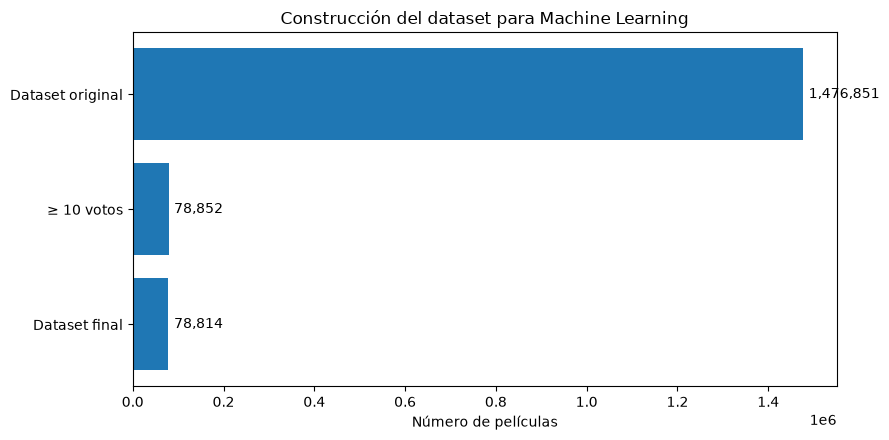

In [134]:
data_funnel = pd.DataFrame({
    "Etapa": [
        "Dataset original",
        "≥ 10 votos",
        "Dataset final"
    ],
    "Observaciones": [
        len(df),
        (df["vote_count"] >= 10).sum(),
        len(df_model)
    ]
})

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.barh(
    data_funnel["Etapa"],
    data_funnel["Observaciones"]
)

ax.invert_yaxis()

ax.set_xlabel("Número de películas")
ax.set_title("Construcción del dataset para Machine Learning")

ax.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in data_funnel["Observaciones"]
    ],
    padding=4
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "dataset_funnel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El principal criterio de reducción del dataset es exigir al menos 10 votos para considerar `vote_average` como variable objetivo. Este filtro reduce considerablemente el número de observaciones.

Se verificó además que todas las películas que cumplen `vote_count >= 10` presentan estado `Released` y `vote_average > 0`. Las 38 observaciones adicionales eliminadas en la preparación final corresponden a registros sin fecha de estreno disponible, necesaria para generar las variables temporales.

## 14. Definición de features y separación train-test

La variable objetivo del problema de regresión es `vote_average`.

Se excluyen `id` y `vote_count` de los predictores. El primero constituye únicamente un identificador y el segundo fue utilizado para establecer el criterio mínimo de diez votos, pero no se desea utilizar como predictor de la puntuación.

También se descartan las variables originales que ya fueron reemplazadas por características derivadas, así como aquellas de muy alta cardinalidad que requerirían un tratamiento específico.

La separación entre entrenamiento y test se realiza antes de calcular parámetros de imputación, escalado o codificación, con el objetivo de evitar fuga de información (*data leakage*).

In [95]:
from sklearn.model_selection import train_test_split

features = [
    "runtime",
    "log_budget",
    "budget_reported",
    "adult",
    "original_language",
    "genres",
    "release_year",
    "release_decade",
    "n_genres",
    "n_spoken_languages",
    "n_production_countries",
    "n_production_companies"
]

X = df_model[features].copy()
y = df_model["vote_average"].copy()

# Los géneros faltantes se representan como ausencia de información
X["genres"] = X["genres"].fillna("")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (63051, 12)
Test:  (15763, 12)


In [96]:
target_split_summary = pd.DataFrame({
    "Train": y_train.describe(),
    "Test": y_test.describe()
})

target_split_summary

,Train,Test
count,63051.000000,15763.000000
mean,6.131046,6.141354
std,1.029985,1.020241
min,1.179000,1.250000
25%,5.500000,5.518000
50%,6.200000,6.202000
75%,6.833000,6.831500
max,10.000000,10.000000


In [97]:
print("Media:")
print(f"Train: {y_train.mean():.3f}")
print(f"Test:  {y_test.mean():.3f}")

print("\nDesvío estándar:")
print(f"Train: {y_train.std():.3f}")
print(f"Test:  {y_test.std():.3f}")

Media:
Train: 6.131
Test:  6.141

Desvío estándar:
Train: 1.030
Test:  1.020


### Verificación de la partición

La partición conserva una distribución muy similar de la variable objetivo en ambos conjuntos. `vote_average` presenta una media de 6.131 en entrenamiento y 6.141 en test, mientras que los desvíos estándar son 1.030 y 1.020, respectivamente.

Por lo tanto, no se observan diferencias relevantes en la distribución del target entre ambos subconjuntos y se continúa con la preparación de los predictores.

## 15. Tratamiento de valores faltantes y outliers

Luego de realizar la separación entre entrenamiento y test, se procede al tratamiento de valores faltantes y extremos.

Las transformaciones que requieren calcular parámetros a partir de los datos se ajustan exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplican al conjunto de test. De esta manera se evita introducir información del conjunto de prueba durante la preparación de los datos.

Para `runtime`, los valores iguales o menores que cero fueron previamente considerados como faltantes. Debido a la baja proporción de estos casos y a la presencia de valores extremos en la distribución, se utilizará la mediana del conjunto de entrenamiento para su imputación.

En `log_budget`, los valores faltantes corresponden a películas para las cuales el presupuesto no se encuentra informado. Se conserva la variable `budget_reported` como indicador de esta situación y se imputa `log_budget` mediante la mediana calculada en entrenamiento.

Por otra parte, los valores extremos no se eliminan automáticamente, ya que pueden representar observaciones válidas. Se analizará su magnitud antes de decidir si resulta necesario aplicar alguna técnica para reducir su influencia.

### 15.1 Faltantes en train y test

In [98]:
missing_train_test = pd.DataFrame({
    "Train_n": X_train.isna().sum(),
    "Train_%": X_train.isna().mean() * 100,
    "Test_n": X_test.isna().sum(),
    "Test_%": X_test.isna().mean() * 100
})

missing_train_test[
    (missing_train_test["Train_n"] > 0) |
    (missing_train_test["Test_n"] > 0)
].round(2)

,Train_n,Train_%,Test_n,Test_%
runtime,936,1.48,239,1.52
log_budget,51425,81.56,12877,81.69


### 15.2 Calculo de medianas exclusivamente con train

In [99]:
runtime_median = X_train["runtime"].median()
log_budget_median = X_train["log_budget"].median()

print(f"Mediana de runtime en train: {runtime_median:.2f}")
print(f"Mediana de log_budget en train: {log_budget_median:.2f}")

Mediana de runtime en train: 94.00
Mediana de log_budget en train: 15.60


### 15.3 Imputaciones

In [100]:
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

In [101]:
# Imputación utilizando únicamente parámetros calculados en train

X_train_prep["runtime"] = X_train_prep["runtime"].fillna(runtime_median)
X_test_prep["runtime"] = X_test_prep["runtime"].fillna(runtime_median)

X_train_prep["log_budget"] = X_train_prep["log_budget"].fillna(log_budget_median)
X_test_prep["log_budget"] = X_test_prep["log_budget"].fillna(log_budget_median)

In [102]:
print("Faltantes después de la imputación:")
print()
print("Train:")
print(X_train_prep[["runtime", "log_budget"]].isna().sum())

print("\nTest:")
print(X_test_prep[["runtime", "log_budget"]].isna().sum())

Faltantes después de la imputación:

Train:
runtime       0
log_budget    0
dtype: int64

Test:
runtime       0
log_budget    0
dtype: int64


### 15.4 Análisis de los outliers

In [104]:
numeric_to_check = [
    "runtime",
    "log_budget",
    "release_year",
    "n_genres",
    "n_spoken_languages",
    "n_production_countries",
    "n_production_companies"
]

outlier_summary = []

for col in numeric_to_check:
    q1 = X_train_prep[col].quantile(0.25)
    q3 = X_train_prep[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = (
        (X_train_prep[col] < lower) |
        (X_train_prep[col] > upper)
    ).sum()

    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Límite inferior": lower,
        "Límite superior": upper,
        "N outliers": n_outliers,
        "% outliers": n_outliers / len(X_train_prep) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.round(2)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers,% outliers
0,runtime,85.0,106.0,21.0,53.5,137.5,9533,15.12
1,log_budget,15.6,15.6,0.0,15.6,15.6,11626,18.44
2,release_year,1985.0,2016.0,31.0,1938.5,2062.5,2466,3.91
3,n_genres,1.0,3.0,2.0,-2.0,6.0,40,0.06
4,n_spoken_languages,1.0,1.0,0.0,1.0,1.0,12596,19.98
5,n_production_countries,1.0,1.0,0.0,1.0,1.0,13833,21.94
6,n_production_companies,1.0,3.0,2.0,-2.0,6.0,1977,3.14


### Tratamiento de outliers

La aplicación exploratoria del criterio del rango intercuartílico (IQR) permitió identificar valores alejados de la región central de las distribuciones. Sin embargo, los resultados muestran que este criterio no resulta adecuado para aplicar una eliminación automática de observaciones en todas las variables.

En `runtime`, el criterio identifica como extremos valores inferiores a 53,5 minutos o superiores a 137,5 minutos, incluyendo potencialmente cortometrajes y películas de larga duración que pueden constituir observaciones válidas.

En variables discretas de conteo, como el número de idiomas o países de producción, el IQR puede ser igual a cero debido a la elevada concentración en un único valor. En estos casos, cualquier valor diferente de la moda queda identificado como outlier aunque sea perfectamente válido.

Una situación similar ocurre con `log_budget`, debido a la elevada proporción de presupuestos originalmente no informados e imputados mediante la mediana.

Por estos motivos no se eliminan ni se recortan automáticamente las observaciones identificadas mediante IQR. En el caso del presupuesto, su fuerte asimetría ya fue mitigada mediante una transformación logarítmica. Los restantes valores extremos se conservan al considerarse potencialmente representativos de la variabilidad real del dataset.

## 16. Codificación de variables categóricas

Los algoritmos de Machine Learning requieren trabajar con representaciones numéricas, por lo que las variables categóricas deben ser transformadas.

La variable `genres` es multietiqueta, ya que una película puede pertenecer simultáneamente a varios géneros. Por este motivo se aplica una codificación *multi-hot*, generando una variable binaria independiente para cada género.

En el caso de `original_language`, se aplica one-hot encoding. Para evitar generar variables asociadas a idiomas con muy pocas observaciones, las categorías con menos de 100 apariciones en el conjunto de entrenamiento se agrupan bajo la categoría `Other`.

Tanto la identificación de los géneros como la selección de idiomas frecuentes se realiza exclusivamente sobre el conjunto de entrenamiento. Posteriormente se aplica la misma estructura de columnas al conjunto de test.

### 16.1 genre

In [105]:
# Multi-hot encoding de géneros

genres_train = (
    X_train_prep["genres"]
    .fillna("")
    .str.get_dummies(sep=", ")
)

genres_test = (
    X_test_prep["genres"]
    .fillna("")
    .str.get_dummies(sep=", ")
)

# Test debe tener exactamente las mismas columnas aprendidas en train
genres_test = genres_test.reindex(
    columns=genres_train.columns,
    fill_value=0
)

# Prefijo para identificar fácilmente estas variables
genres_train.columns = ["genre_" + col for col in genres_train.columns]
genres_test.columns = ["genre_" + col for col in genres_test.columns]

print(f"Géneros identificados en train: {genres_train.shape[1]}")
genres_train.sum().sort_values(ascending=False)

Géneros identificados en train: 19


genre_Drama              26438
genre_Comedy             20264
genre_Thriller           10455
genre_Romance             9274
genre_Action              8692
genre_Horror              7820
genre_Crime               6249
genre_Animation           5099
genre_Adventure           4925
genre_Documentary         4874
genre_Family              4679
genre_Science Fiction     4242
genre_Fantasy             3834
genre_Mystery             3748
genre_TV Movie            3583
genre_Music               2477
genre_History             2202
genre_War                 1751
genre_Western             1101
dtype: int64

### 16.2 original_language

In [106]:
# Frecuencia de idiomas calculada exclusivamente en train

language_counts = X_train_prep["original_language"].value_counts()

min_language_frequency = 100

common_languages = language_counts[
    language_counts >= min_language_frequency
].index

coverage = (
    X_train_prep["original_language"].isin(common_languages).mean() * 100
)

print(f"Idiomas originales en train: {language_counts.size}")
print(f"Idiomas con al menos {min_language_frequency} películas: {len(common_languages)}")
print(f"Cobertura de esos idiomas: {coverage:.2f}%")

Idiomas originales en train: 107
Idiomas con al menos 100 películas: 32
Cobertura de esos idiomas: 98.60%


In [107]:
# Agrupación de idiomas poco frecuentes

lang_train = X_train_prep["original_language"].where(
    X_train_prep["original_language"].isin(common_languages),
    "Other"
)

lang_test = X_test_prep["original_language"].where(
    X_test_prep["original_language"].isin(common_languages),
    "Other"
)

# One-hot encoding
lang_train = pd.get_dummies(
    lang_train,
    prefix="lang",
    dtype=int
)

lang_test = pd.get_dummies(
    lang_test,
    prefix="lang",
    dtype=int
)

# Igualar las columnas de test a las aprendidas en train
lang_test = lang_test.reindex(
    columns=lang_train.columns,
    fill_value=0
)

print(f"Variables generadas para idioma: {lang_train.shape[1]}")

Variables generadas para idioma: 33


### 16.3 Construcción de los datasets ya codificados

In [108]:
# Eliminamos las columnas categóricas originales
X_train_encoded = X_train_prep.drop(
    columns=["genres", "original_language"]
).copy()

X_test_encoded = X_test_prep.drop(
    columns=["genres", "original_language"]
).copy()

# Bool a entero
X_train_encoded["adult"] = X_train_encoded["adult"].astype(int)
X_test_encoded["adult"] = X_test_encoded["adult"].astype(int)

# Agregamos las variables codificadas
X_train_encoded = pd.concat(
    [
        X_train_encoded.reset_index(drop=True),
        genres_train.reset_index(drop=True),
        lang_train.reset_index(drop=True)
    ],
    axis=1
)

X_test_encoded = pd.concat(
    [
        X_test_encoded.reset_index(drop=True),
        genres_test.reset_index(drop=True),
        lang_test.reset_index(drop=True)
    ],
    axis=1
)

print(f"Train antes de codificar: {X_train_prep.shape}")
print(f"Train después de codificar: {X_train_encoded.shape}")

print(f"\nTest antes de codificar: {X_test_prep.shape}")
print(f"Test después de codificar: {X_test_encoded.shape}")

print(
    f"\nFaltantes restantes en train: "
    f"{X_train_encoded.isna().sum().sum()}"
)
print(
    f"Faltantes restantes en test: "
    f"{X_test_encoded.isna().sum().sum()}"
)

Train antes de codificar: (63051, 12)
Train después de codificar: (63051, 62)

Test antes de codificar: (15763, 12)
Test después de codificar: (15763, 62)

Faltantes restantes en train: 0
Faltantes restantes en test: 0


## 17. Escalado de variables

Luego de la imputación y codificación, todas las variables se encuentran representadas numéricamente y no presentan valores faltantes.

Dado que las variables poseen escalas muy diferentes —por ejemplo, `release_year`, `runtime` y las variables binarias generadas mediante codificación— se aplica una estandarización para llevarlas a una escala comparable.

Se utiliza `StandardScaler`, que centra cada variable respecto de su media y la escala según su desvío estándar. Esta transformación resulta especialmente relevante para técnicas posteriores como PCA, cuyo resultado depende de la escala de las variables.

Siguiendo el criterio utilizado en las etapas anteriores, el escalador se ajusta exclusivamente sobre el conjunto de entrenamiento. Los parámetros obtenidos se utilizan luego para transformar tanto train como test, evitando fuga de información.

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# El escalador aprende media y desvío únicamente de train
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Test se transforma usando exactamente los parámetros aprendidos en train
X_test_scaled = scaler.transform(X_test_encoded)

# Volvemos a DataFrame para conservar los nombres de las variables
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_encoded.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_encoded.columns
)

print(f"Train escalado: {X_train_scaled.shape}")
print(f"Test escalado:  {X_test_scaled.shape}")

Train escalado: (63051, 62)
Test escalado:  (15763, 62)


In [110]:
scaling_check = pd.DataFrame({
    "media": X_train_scaled.mean(),
    "std": X_train_scaled.std()
})

scaling_check.head(15).round(3)

,media,std
runtime,0.0,1.0
log_budget,-0.0,1.0
budget_reported,-0.0,1.0
adult,0.0,1.0
release_year,-0.0,1.0
release_decade,0.0,1.0
n_genres,-0.0,1.0
n_spoken_languages,-0.0,1.0
n_production_countries,-0.0,1.0
n_production_companies,-0.0,1.0


## 18. Selección de features

Luego del preprocesamiento se dispone de 62 variables predictoras. Una dimensionalidad elevada puede incorporar información redundante o poco relevante, aumentar el costo computacional y dificultar la interpretación.

La selección de features busca conservar un subconjunto de las variables originales, a diferencia de métodos de extracción como PCA, que generan nuevas variables a partir de combinaciones de las existentes.

Para este problema se consideran dos criterios:

1. **Redundancia y conocimiento del problema:** se revisan variables que contienen información equivalente o fuertemente relacionada.
2. **Relevancia predictiva respecto del target:** se utiliza Información Mutua para estimar cuánto aporta cada feature a la predicción de `vote_average`.

Todo el análisis de selección se realiza exclusivamente sobre el conjunto de entrenamiento para evitar utilizar información del conjunto de test.

### 18.1 Primero: redundancias evidentes

In [111]:
redundancy_check = X_train_encoded[
    [
        "release_year",
        "release_decade",
        "runtime",
        "log_budget",
        "n_genres",
        "n_spoken_languages",
        "n_production_countries",
        "n_production_companies"
    ]
].corr(method="spearman")

redundancy_check.round(3)

,release_year,release_decade,runtime,log_budget,n_genres,n_spoken_languages,n_production_countries,n_production_companies
release_year,1.000,0.975,0.134,0.041,-0.001,0.037,0.046,0.166
release_decade,0.975,1.000,0.134,0.041,0.001,0.036,0.044,0.161
runtime,0.134,0.134,1.000,0.139,0.108,0.179,0.145,0.216
log_budget,0.041,0.041,0.139,1.000,0.092,0.059,0.093,0.151
n_genres,-0.001,0.001,0.108,0.092,1.000,0.090,0.088,0.169
n_spoken_languages,0.037,0.036,0.179,0.059,0.090,1.000,0.255,0.198
n_production_countries,0.046,0.044,0.145,0.093,0.088,0.255,1.000,0.426
n_production_companies,0.166,0.161,0.216,0.151,0.169,0.198,0.426,1.000


In [112]:
print(
    "Correlación release_year vs release_decade:",
    X_train_encoded["release_year"].corr(
        X_train_encoded["release_decade"],
        method="spearman"
    )
)

Correlación release_year vs release_decade: 0.9750842883241105


### 18.2 Información Mutua

In [113]:
from sklearn.feature_selection import mutual_info_regression

# Identificamos features binarias/categóricas codificadas
discrete_mask = np.array([
    (
        col == "adult"
        or col == "budget_reported"
        or col.startswith("genre_")
        or col.startswith("lang_")
    )
    for col in X_train_encoded.columns
])

print(f"Features totales: {len(discrete_mask)}")
print(f"Features tratadas como discretas: {discrete_mask.sum()}")
print(f"Features tratadas como continuas: {(~discrete_mask).sum()}")

Features totales: 62
Features tratadas como discretas: 54
Features tratadas como continuas: 8


### 18.3 Calcular MI

In [115]:
mi_scores = mutual_info_regression(
    X_train_encoded,
    y_train.reset_index(drop=True),
    discrete_features=discrete_mask,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "MI": mi_scores
}).sort_values(
    "MI",
    ascending=False
).reset_index(drop=True)

mi_results.head(25)

,Feature,MI
0,runtime,0.208693
1,release_year,0.179556
2,release_decade,0.149823
3,n_production_companies,0.143903
4,n_genres,0.106517
5,n_spoken_languages,0.060239
6,n_production_countries,0.055665
7,log_budget,0.052108
8,budget_reported,0.000000
9,adult,0.000000


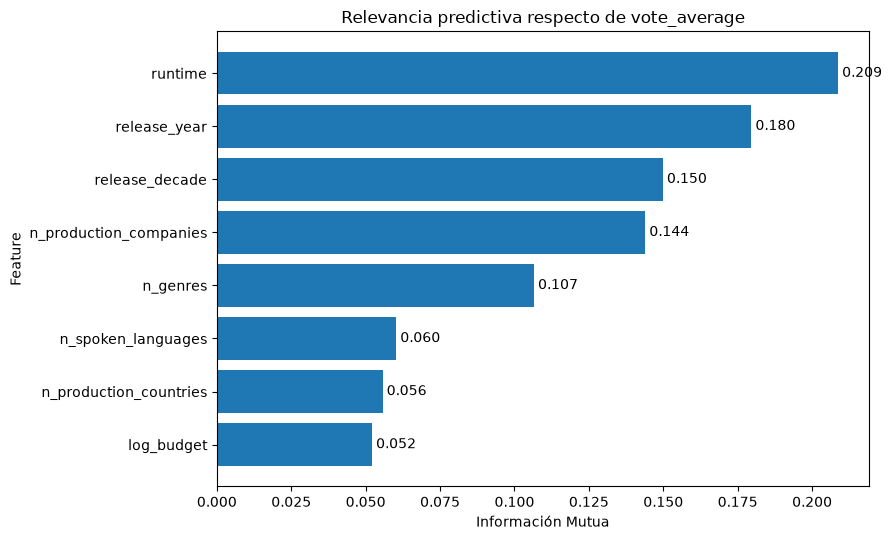

In [132]:
mi_positive = (
    mi_results[
        mi_results["MI"] > 0
    ]
    .sort_values("MI")
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    mi_positive["Feature"],
    mi_positive["MI"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in mi_positive["MI"]
    ],
    padding=3
)

ax.set_xlabel("Información Mutua")
ax.set_ylabel("Feature")
ax.set_title(
    "Relevancia predictiva respecto de vote_average"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "mutual_information.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [117]:
mi_results.tail(15)

,Feature,MI
47,lang_ml,0.0
48,lang_nl,0.0
49,lang_no,0.0
50,lang_pl,0.0
51,lang_pt,0.0
52,lang_ro,0.0
53,lang_ru,0.0
54,lang_sv,0.0
55,lang_ta,0.0
56,lang_te,0.0


### Selección final de features

El análisis de Información Mutua muestra una clara diferencia entre un conjunto reducido de variables con relevancia predictiva y el resto de las features, cuyos scores resultan iguales a cero.

`runtime` presenta la mayor Información Mutua respecto de `vote_average`, seguida por las variables temporales `release_year` y `release_decade`, la cantidad de compañías productoras, la cantidad de géneros, idiomas y países de producción, y `log_budget`.

Sin embargo, `release_year` y `release_decade` presentan una correlación de Spearman de aproximadamente 0,975. Esta asociación elevada es esperable, dado que la década fue generada directamente a partir del año de estreno. Para evitar redundancia se conserva únicamente `release_year`, que además presenta un score de Información Mutua superior.

Las variables binarias correspondientes a géneros e idiomas individuales no presentan Información Mutua detectable de manera univariada con el target. Esto no implica necesariamente ausencia absoluta de relación, sino que su aporte individual resulta reducido bajo este criterio.

Por lo tanto, como resultado del proceso de selección se conservan siete features:

- `runtime`
- `release_year`
- `n_production_companies`
- `n_genres`
- `n_spoken_languages`
- `n_production_countries`
- `log_budget`

De esta forma, el espacio de variables se reduce de 62 a 7 dimensiones, conservando aquellas que presentan mayor relevancia predictiva y evitando una redundancia temporal evidente.

In [118]:
selected_features = [
    "runtime",
    "release_year",
    "n_production_companies",
    "n_genres",
    "n_spoken_languages",
    "n_production_countries",
    "log_budget"
]

X_train_selected = X_train_scaled[selected_features].copy()
X_test_selected = X_test_scaled[selected_features].copy()

print(f"Features antes de selección: {X_train_scaled.shape[1]}")
print(f"Features después de selección: {X_train_selected.shape[1]}")

X_train_selected.head()

Features antes de selección: 62
Features después de selección: 7


,runtime,release_year,n_production_companies,n_genres,n_spoken_languages,n_production_countries,log_budget
0,-2.468847,-1.769133,-0.544247,-1.044159,-0.341887,-1.664851,0.079339
1,0.565978,0.588890,-0.544247,-1.044159,1.081911,-0.287014,0.079339
2,-0.619049,0.824692,-0.017518,-1.044159,2.505708,-0.287014,0.079339
3,1.606489,-1.297528,-0.017518,-0.085328,2.505708,1.090823,0.079339
4,-0.561243,0.117285,-0.544247,-0.085328,1.081911,-0.287014,0.079339


## 19. Reducción de dimensionalidad mediante PCA

Como segunda estrategia de reducción de dimensionalidad se aplica Análisis de Componentes Principales (PCA).

A diferencia de la selección de features realizada anteriormente, PCA no conserva un subconjunto de las variables originales, sino que genera nuevas variables —los componentes principales— como combinaciones lineales de las features existentes.

Los componentes se ordenan según la cantidad de varianza que explican, de manera que los primeros concentran la mayor proporción de información presente en los datos.

PCA se aplica sobre las 62 features previamente codificadas y estandarizadas, utilizando exclusivamente el conjunto de entrenamiento para ajustar la transformación. Posteriormente, la misma transformación se aplica al conjunto de test.

Se evaluará la cantidad de componentes necesaria para conservar distintos niveles de varianza acumulada, utilizando como referencia un umbral del 80 %.

### 19.1 PCA con todos los componentes

In [120]:
from sklearn.decomposition import PCA

pca_full = PCA()

pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Componente": np.arange(1, len(explained_variance) + 1),
    "Varianza explicada": explained_variance,
    "Varianza acumulada": cumulative_variance
})

pca_summary.head(15)

,Componente,Varianza explicada,Varianza acumulada
0,1,0.045357,0.045357
1,2,0.039916,0.085274
2,3,0.032259,0.117533
3,4,0.031271,0.148804
4,5,0.026039,0.174843
5,6,0.025008,0.199850
6,7,0.022489,0.222339
7,8,0.021334,0.243673
8,9,0.020306,0.263979
9,10,0.018730,0.282709


### 19.2 Componentes necesarios

In [121]:
for threshold in [0.70, 0.80, 0.90, 0.95]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    
    print(
        f"{threshold*100:.0f}% de varianza: "
        f"{n_components} componentes"
    )

70% de varianza: 36 componentes
80% de varianza: 42 componentes
90% de varianza: 49 componentes
95% de varianza: 53 componentes


### 19.3 Gráfico de varianza acumulada

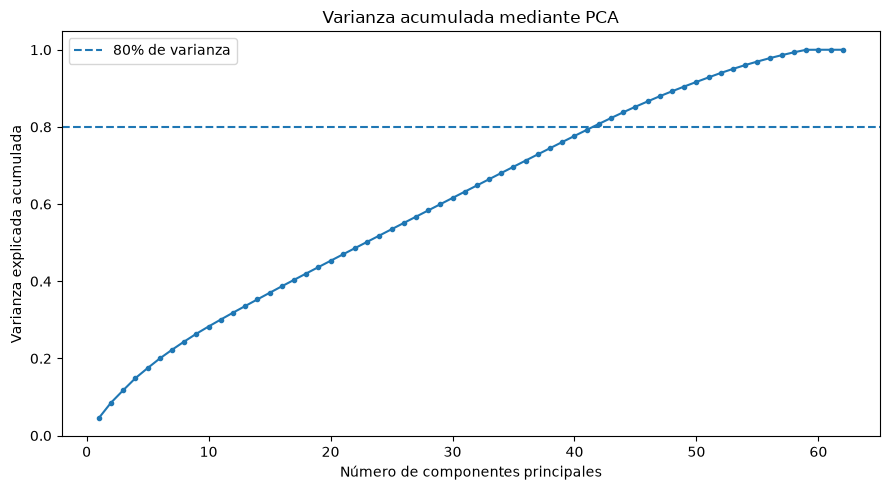

In [122]:
plt.figure(figsize=(9, 5))

plt.plot(
    pca_summary["Componente"],
    pca_summary["Varianza acumulada"],
    marker="o",
    markersize=3
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% de varianza"
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza acumulada mediante PCA")
plt.legend()

plt.tight_layout()
plt.show()

### 19.4 Aplicación de PCA conservando 80 %

In [123]:
pca = PCA(n_components=0.80)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensiones originales: {X_train_scaled.shape[1]}")
print(f"Componentes PCA seleccionados: {pca.n_components_}")
print(
    f"Varianza acumulada conservada: "
    f"{pca.explained_variance_ratio_.sum()*100:.2f}%"
)

print(f"\nTrain PCA: {X_train_pca.shape}")
print(f"Test PCA:  {X_test_pca.shape}")

Dimensiones originales: 62
Componentes PCA seleccionados: 42
Varianza acumulada conservada: 80.78%

Train PCA: (63051, 42)
Test PCA:  (15763, 42)


### 19.5 Paso a DAtaFrame

In [124]:
pc_names = [
    f"PC{i+1}"
    for i in range(pca.n_components_)
]

X_train_pca = pd.DataFrame(
    X_train_pca,
    columns=pc_names
)

X_test_pca = pd.DataFrame(
    X_test_pca,
    columns=pc_names
)

X_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42
0,-4.021490,1.884470,-0.028224,-0.175879,0.186575,-0.673229,-0.026656,-0.724924,0.000727,-0.739041,0.156990,-0.715762,-0.969586,-0.011954,-0.314087,-0.061597,-0.022018,-0.216675,-0.042946,-0.034343,0.120362,0.278310,0.097830,-0.128683,0.077764,-0.025945,-0.058709,-0.059944,0.001255,0.105515,-0.044379,0.037359,0.005555,0.033854,-0.002293,0.256908,-0.194682,-0.322000,-0.281885,-0.091906,-0.410896,-0.841455
1,0.332684,-2.370673,-0.308932,0.456065,-0.209728,-0.085616,0.501877,0.802863,-1.803681,-3.106597,-0.331631,-1.488510,-1.030382,0.511140,-0.428469,-2.346314,2.364071,3.244677,0.953176,0.786270,-2.134164,-3.807089,-1.859512,-3.771014,-4.224227,-1.137208,0.990410,2.070085,-1.997707,2.173869,-2.171070,-0.587927,2.714353,-1.871638,3.463434,-1.925495,5.322726,-4.545824,-3.394779,5.026080,2.263330,5.218168
2,0.304276,-2.223567,-0.634970,0.422537,0.595280,-1.001441,-0.159565,-0.653286,0.010362,-0.155040,-1.045557,-0.114250,-0.412729,1.958880,3.481489,-0.560702,-1.839073,3.116245,-0.071864,1.213807,-0.364070,1.299215,-0.268794,-0.045922,0.057051,0.292292,0.093501,-0.135482,-0.073410,-0.039129,0.032704,0.053695,0.141814,-0.164287,-0.073165,0.688275,-0.144242,-0.365895,0.218304,-0.580043,-0.501173,-0.333547
3,0.638855,-1.016588,-1.967778,-2.497521,2.365967,0.830911,1.284281,-1.218742,-0.943492,0.474591,-0.642030,0.036676,0.262793,-0.084577,-0.263751,-0.459484,-0.650237,-0.219948,-0.048417,0.138831,0.035448,-0.173211,0.243930,-0.220187,-0.022526,0.435751,-0.048985,0.157011,0.142886,0.032372,0.121325,-0.174173,-0.072576,0.110467,-0.004566,-0.580311,0.275109,0.307943,-0.043448,-0.023301,0.084233,-1.038307
4,-0.144735,-0.666001,-0.123454,-0.205617,0.177205,1.773957,-0.222023,-0.459902,-0.358321,0.143920,0.904349,-0.350996,-0.466777,0.781973,0.275041,0.054935,0.291590,-0.266370,0.093123,-0.074323,0.181455,0.127674,0.084000,0.027979,0.241026,-0.062376,-0.095440,-0.058514,0.033261,0.069190,-0.065787,-0.032843,-0.025741,0.023043,0.001345,-0.005862,-0.230589,0.115163,-0.324528,-0.213242,-0.395386,0.310683


### Interpretación del PCA

El análisis de componentes principales muestra que la varianza del conjunto de datos se encuentra distribuida entre un número relativamente elevado de dimensiones.

Para conservar al menos el 80 % de la varianza total son necesarios 42 componentes principales, que explican en conjunto aproximadamente el 80,78 % de la varianza. Para alcanzar el 90 % se requieren 49 componentes y para el 95 %, 53.

Por lo tanto, PCA permite reducir la dimensionalidad de 62 a 42 variables manteniendo aproximadamente el 80 % de la información medida en términos de varianza. Sin embargo, la reducción obtenida es moderada y no se observa un punto de codo claramente definido en la curva de varianza acumulada, lo que sugiere que la información se encuentra distribuida entre múltiples dimensiones.

Este resultado contrasta con la selección de features mediante Información Mutua, que permitió reducir el conjunto a 7 variables originales con relevancia predictiva detectable respecto de `vote_average`.

Ambas técnicas persiguen objetivos diferentes. La selección de features conserva la interpretación de las variables originales y utiliza información del target para evaluar su relevancia predictiva. PCA, en cambio, es una técnica no supervisada que busca conservar la mayor varianza posible de los predictores, generando nuevas variables que son combinaciones lineales de las originales.

En este problema, la selección de features ofrece una reducción mucho mayor y conserva una interpretación directa de las variables, mientras que PCA permite retener información global del conjunto de predictores, aunque a costa de una menor interpretabilidad.

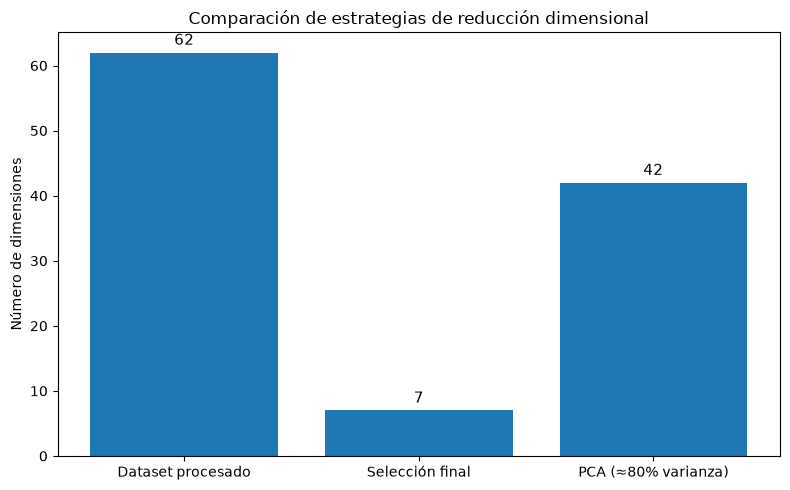

In [135]:
dimensionality_comparison = pd.DataFrame({
    "Estrategia": [
        "Dataset procesado",
        "Selección final",
        "PCA (≈80% varianza)"
    ],
    "Dimensiones": [
        X_train_scaled.shape[1],
        X_train_selected.shape[1],
        X_train_pca.shape[1]
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    dimensionality_comparison["Estrategia"],
    dimensionality_comparison["Dimensiones"]
)

ax.bar_label(
    bars,
    labels=[
        str(value)
        for value in dimensionality_comparison["Dimensiones"]
    ],
    padding=3,
    fontsize=11
)

ax.set_ylabel("Número de dimensiones")
ax.set_title("Comparación de estrategias de reducción dimensional")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "dimensionality_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Conclusiones

El análisis permitió explorar y preparar el dataset de películas de TMDB para un posible problema supervisado de regresión cuyo objetivo es predecir `vote_average`.

Durante el EDA se identificaron particularidades relevantes del dataset, entre ellas una elevada cantidad de valores iguales a cero en variables como `budget` y `revenue`, valores extremos potencialmente válidos y variables categóricas y multietiqueta de elevada cardinalidad.

Para obtener una variable objetivo más representativa se decidió trabajar únicamente con películas estrenadas, con `vote_average > 0` y al menos 10 votos. Luego de aplicar estos criterios se conservaron 78.814 observaciones.

La preparación de los datos incluyó:

- tratamiento de valores inconsistentes y faltantes;
- transformación logarítmica del presupuesto;
- creación de nuevas features a partir de fechas y variables multietiqueta;
- separación train-test 80/20;
- imputación utilizando únicamente parámetros obtenidos del conjunto de entrenamiento;
- codificación multi-hot de géneros y one-hot de idiomas;
- estandarización de las variables;
- análisis y tratamiento conceptual de valores extremos;
- selección y extracción de features.

La selección mediante Información Mutua permitió identificar siete variables con mayor relevancia predictiva respecto de `vote_average`: `runtime`, `release_year`, `n_production_companies`, `n_genres`, `n_spoken_languages`, `n_production_countries` y `log_budget`. Además, se eliminó `release_decade` por su elevada redundancia con `release_year`. 

Debe considerarse que `log_budget` presenta una proporción elevada de valores originalmente no informados. Si bien la variable se conservó debido a que mostró relevancia predictiva en el análisis de Información Mutua, su elevada tasa de ausencia constituye una limitación del dataset y sus resultados deben interpretarse con cautela.

Como estrategia alternativa de reducción dimensional se aplicó PCA sobre las 62 variables procesadas. Para conservar aproximadamente el 80 % de la varianza fueron necesarios 42 componentes principales. Esto evidencia que la información global del dataset se encuentra distribuida entre numerosas dimensiones.

En consecuencia, para este problema la selección de features resulta especialmente atractiva por proporcionar una reducción considerable de dimensionalidad manteniendo variables directamente interpretables. PCA ofrece una representación alternativa que conserva una proporción elevada de la varianza, aunque con una reducción menor y a costa de perder interpretabilidad.

El resultado final es un conjunto de datos limpio y preparado para el eventual entrenamiento y evaluación de modelos de regresión, etapa que no forma parte del alcance de este trabajo.